# Main-paper display items — figures and tables with explanations

**Purpose.** This notebook assembles the eight display items of the paper
("The learning-consistent required subsidy", outline: `z-ethan/paper_outline.md`).
Every panel is the already-generated, checked artifact from the analysis
notebooks. This notebook does not redraw any of them. Each item carries a
**source block** that names the notebook and cell that made each panel.
To change a panel, edit it there and re-run this notebook.

**How to read this notebook.** Each section has three parts:
1. A text block that explains the item in plain language.
2. A code cell that composes the panels and writes `figures/FigN_*.png`.
3. A printed draft caption, collected into `exports/captions_main.txt`.

**Language.** We use simplified technical English: short sentences, one
idea per sentence, active voice. Terms of art are kept, but each one is
glossed in the table below.

**What the paper claims, in one paragraph.** Cost assumptions and deployment
targets are usually set independently, so they often contradict each other.
We couple them: Monte Carlo learning-conditional cost worlds feed a capacity
mandate in ReEDS, and the mandate's dual is the subsidy that makes the pair
consistent. The subsidy behaves like a bridge (it decays as the fleet learns)
in cheap worlds, but not in expensive ones. Translated into the US tax
credit, median worlds need 2.0–2.5 times the current base credit, and no
real delivery instrument gets the money out for less than the flat
dollar-per-MW floor.

## Glossary — read this first

We use each term below many times. We give its plain meaning once, here.
The same word always has the same meaning in this notebook.

| Term | Plain meaning |
|---|---|
| **Schedule** | A target path for new US nuclear capacity, in gigawatts (GW), from now to 2050. The paper prices six schedules. It does not rank or endorse them. |
| **Mandate** | A rule added to the model: "at least this much new nuclear capacity must exist in year t." Each schedule becomes one mandate. |
| **ReEDS** | The national power-system planning model (NREL). It chooses the cheapest mix of plants and transmission that meets demand and all rules. |
| **Dual (shadow price)** | The price the model puts on the mandate rule. It equals the yearly rental payment, per kilowatt of mandated capacity, that would just make builders willing to build. Units: dollars per kW per year, in 2024 dollars. A dual of zero means the mandate needs no subsidy that year. |
| **Learning rate** | The percent cost drop each time total built capacity doubles. Example: a 10% learning rate means the second 10 GW costs 10% less per kW than the first 10 GW. |
| **Learning curve** | The cost path that a learning rate produces as capacity grows. |
| **OCC (overnight capital cost)** | The cost to build a plant if it could be built "overnight" — no construction-period interest. Units: \$/kW. |
| **Financed capex** | OCC plus the interest that accrues during the construction years. Long builds raise it. |
| **SMR / large** | The two reactor technology families: small modular reactors, and large conventional reactors. |
| **Cost world** | One complete random draw of all uncertain cost inputs (learning rates, starting costs, build durations, and so on). The Monte Carlo makes 10,000 worlds per schedule. |
| **P5 / P50 / P95 world** | Actual single draws ranked by total program cost: a cheap world (5th percentile), the median world, and an expensive world (95th percentile). |
| **Conditional cost trajectory** | A cost path that is only valid if its paired deployment schedule actually happens. None of our cost fans is a forecast. |
| **ITC (investment tax credit)** | The main US subsidy instrument: the government returns a set percentage of a plant's capital cost through the tax system. The current base credit (section 48E) is 30%, with bonuses up to about 50%. |
| **Model credit convention (i_model)** | The paper's headline rate convention: the credit is valued inside ReEDS's own financing arithmetic, where a credit dollar also carries construction-period carrying cost. Two real designs deliver it (a progress payment during construction, or a placed-in-service claim on the interest-inclusive tax basis), and both cost the government the same present value. The exported companion i_pis = i_model x ccmult converts to a placed-in-service credit on an overnight-cost-only basis. |
| **The floor / instrument menu** | The floor is the minimum net government cost that delivers the required support to every build — a flat dollar-per-MW payment at commissioning, elective pay. The menu prices every instrument as a multiple of it. |
| **κ (kappa) coupling** | A dial for how strongly the two technologies' cost uncertainties move together. κ = 1: what is expensive for one is expensive for the other. κ = 0: independent. |
| **EVPI (expected value of perfect information)** | The most that knowing the true cost world in advance could be worth, as a share of expected program cost. |
| **LP / reduced cost** | ReEDS solves a linear program (LP) — a cost-minimization with linear rules. A builder's "reduced cost" is its cost disadvantage at the optimum; zero means it is competitive at the margin. |

In [1]:
import pandas as pd

import paperlib as P
from paperlib import MC_FIG, MC_EXP, S3_FIG, S3_EXP, S4_FIG, S4_EXP, S3C_EXP, S4C_EXP

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
TO2024 = P.to2024()
print(f"repo: {P.REPO}")
print(f"2004$ -> 2024$ multiplier (from inputs/financials/deflator.csv): {TO2024:.4f}")

repo: C:\Users\ethan\code\research\ReEDS-nuclear-learning
2004$ -> 2024$ multiplier (from inputs/financials/deflator.csv): 1.6590


## Figure 1 — The six schedules, and the cost worlds each one implies

**What this shows.** Panel (a): the six deployment schedules (the "ambition
ladder"), from 117 GW (EIA) to 400 GW (2025 Executive Order) of new capacity
by 2050. One schedule per source type: modeled projection, study assumption,
intergovernmental outlook, consultancy outlook, pledge, policy aspiration.
Panels (b) and (c): for each schedule, the fan of overnight capital cost
(OCC) paths that our Monte Carlo produces **conditional on that schedule
happening** — SMR in (b), large reactors in (c).

**How to read it.** Each fan is a distribution, never a single projection.
The band spans the 5th to 95th percentile of 10,000 joint draws; the middle
line is the median. More ambitious schedules buy more learning, so their
fans sit lower.

**Key results.** The median SMR cost in 2050 falls from about \$5,494/kW
under the least ambitious schedule (EIA, 117 GW) to about \$3,483/kW under
the most ambitious (EO, 400 GW). Across schedules the 5th–95th percentile
span runs from roughly \$1,700 to \$8,200/kW. The wide bands are the point:
a deployment target does not pin down a cost; it pins down a distribution.

**Discipline to keep in every caption.** These are conditional cost
trajectories. Each fan answers: "if this schedule happens, what may costs
do?" It never answers: "what will costs be?"

composed -> z-ethan\paper_figures\figures\Fig1_schedules_and_cost_fans.png  (3965x5512 px)


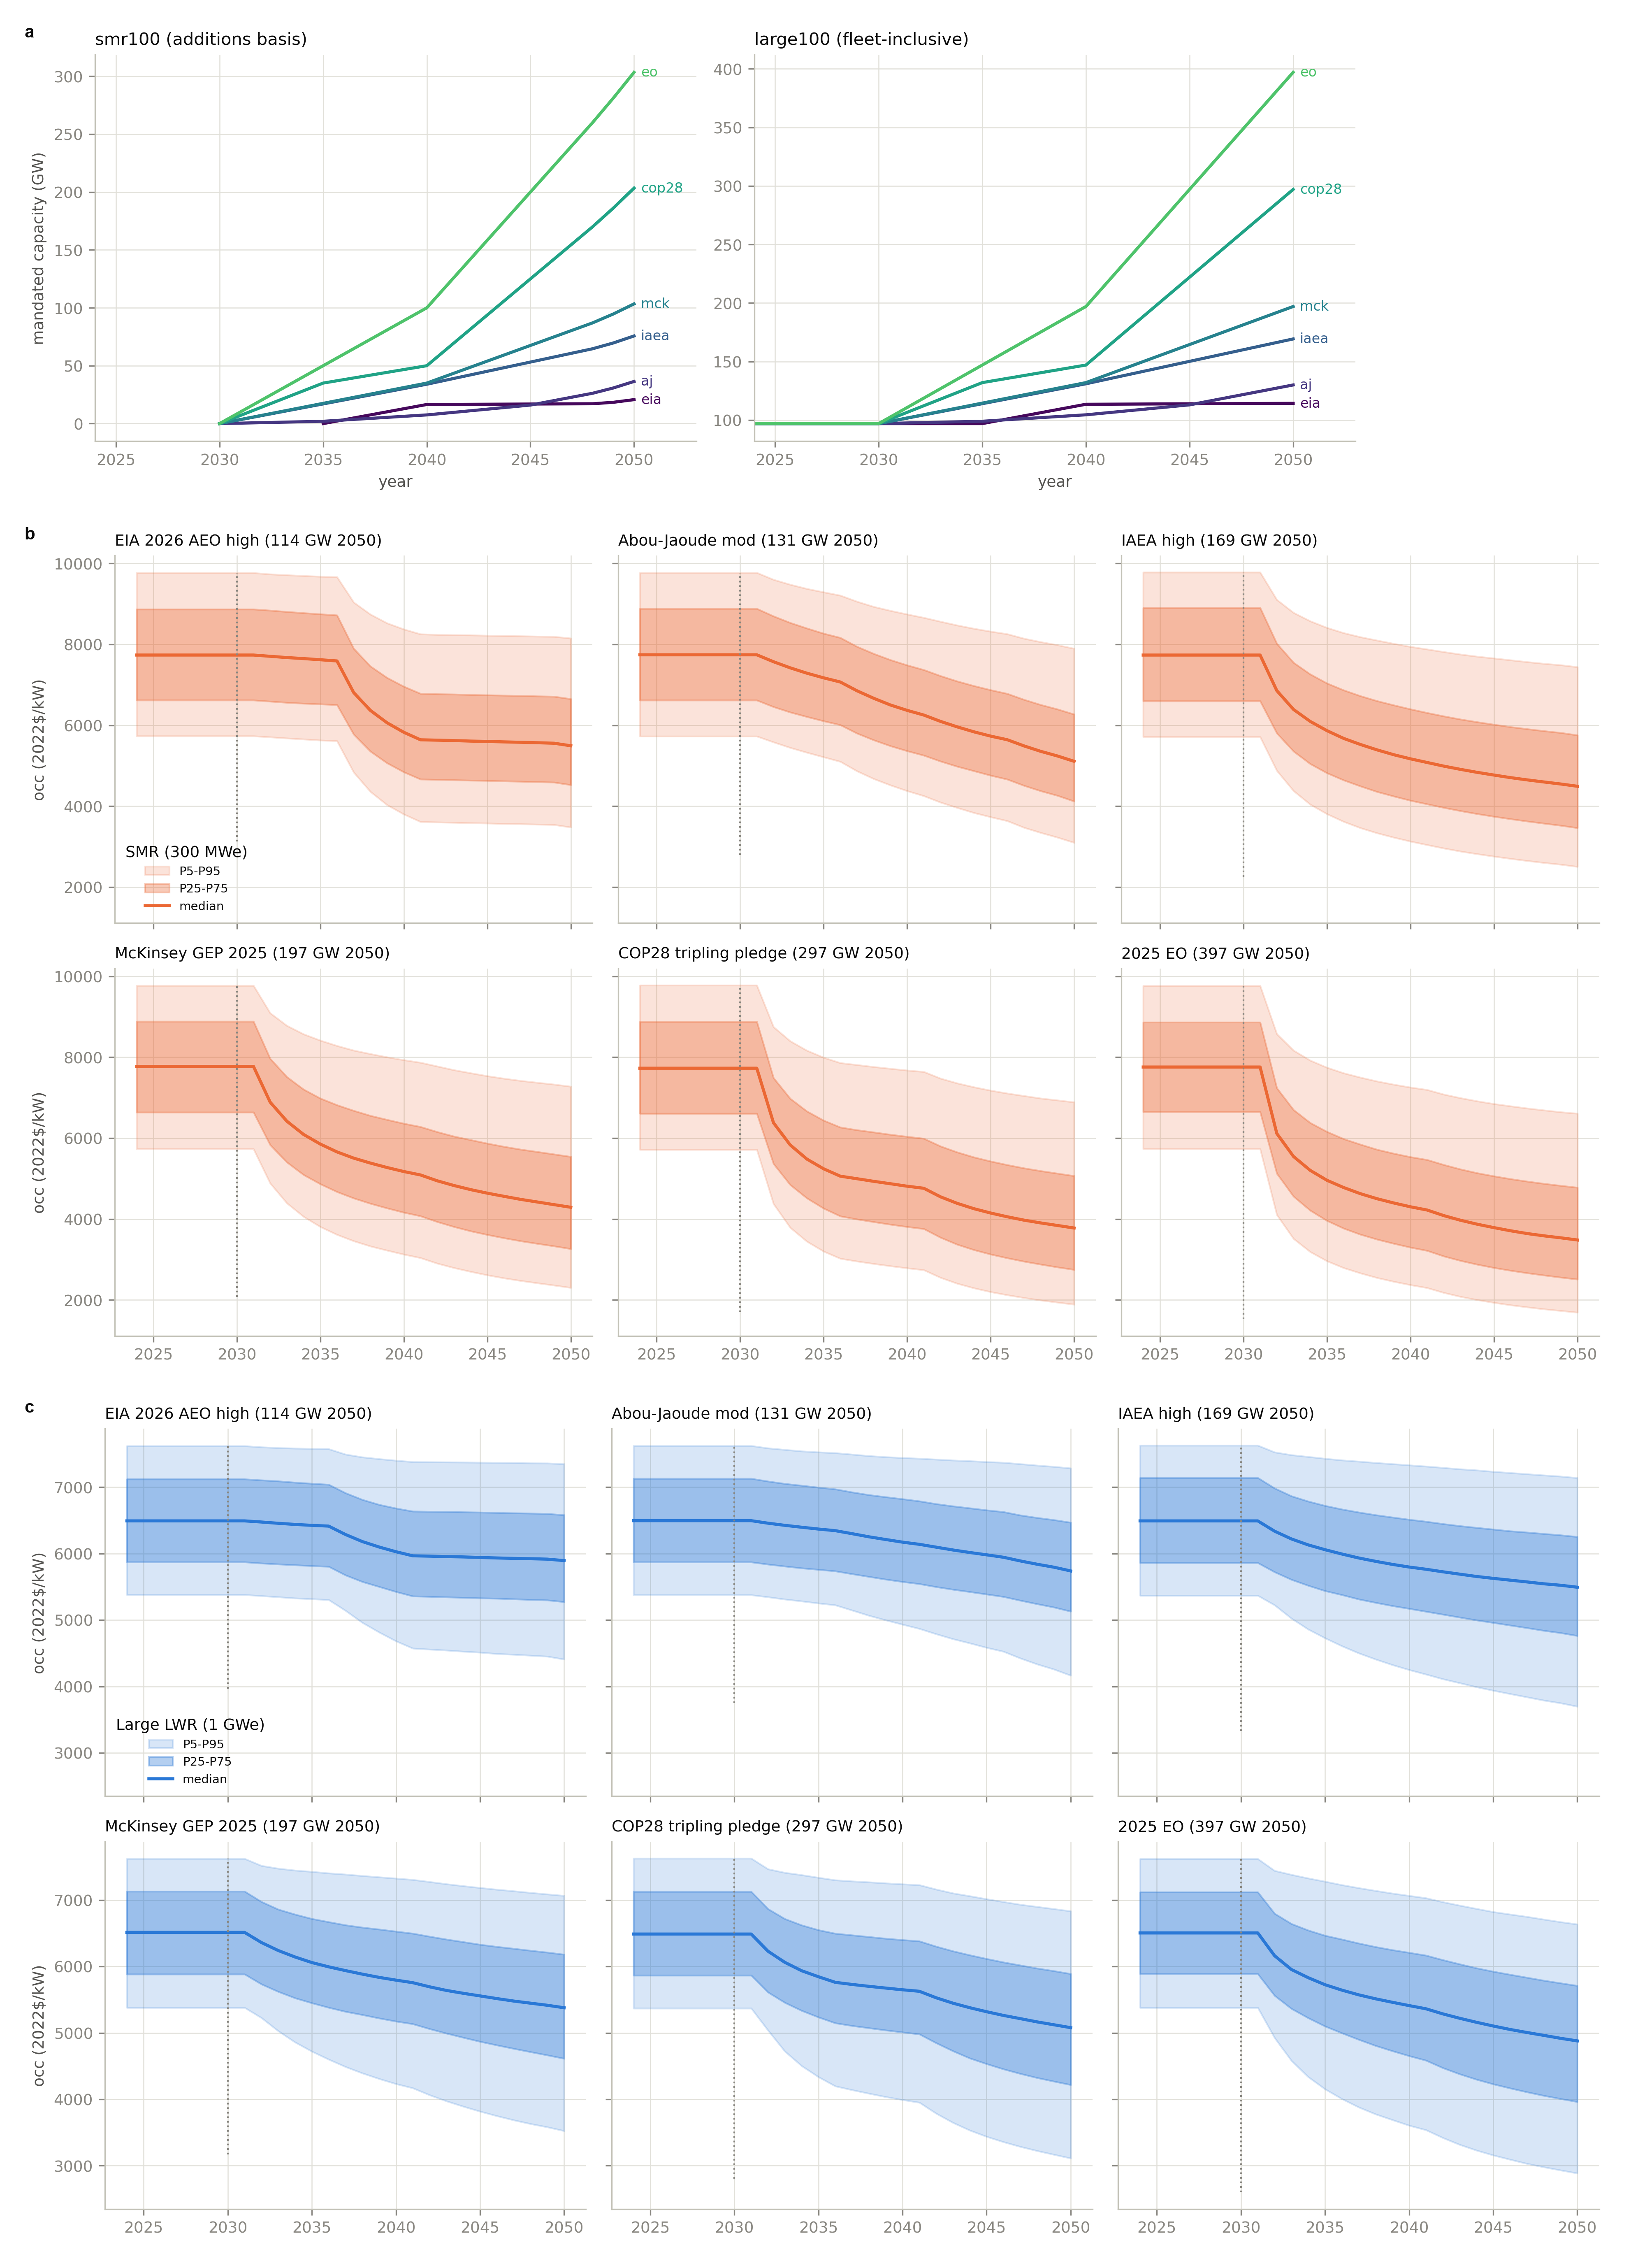

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step3_analysis\figures\f01_mandate_trajectories.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 10) from `inputs/nuclear_learning/nuclear_cap_trajectory_*.csv` (the mandate files ReEDS reads)
- `z-ethan\mc\figures\occ_fans_smr.png` — generated by `mc/mc_cost_trajectories.ipynb` (cell 23) from the in-memory MC results (10,000 joint draws per schedule); percentile export: `mc/exports/mc_occ_percentiles_by_schedule.csv`
- `z-ethan\mc\figures\occ_fans_large.png` — generated by `mc/mc_cost_trajectories.ipynb` (cell 23) from same MC results, large-reactor arrays

SMR P50 OCC in 2050, by schedule token:
smr  eia_aeo_high  P50    5494.0
     abou_jaoude   P50    5110.0
     iaea_high     P50    4493.0
     mckinsey      P50    4291.0
     cop28         P50    3779.0
     eo2025        P50    3483.0
2050 P5-P95 span across schedules and techs: 1,693 - 8,151 $/kW

--- draft caption [Fig 1] ---
Deployment schedules and the conditional cost worlds they imply. (a) Six new-nuclear deployment
schedules for the United States, 117-400 GW by 2050, one per provenance class; the paper prices
these schedules and does not rank them. (b, c) Overnight capital cost fans (5th-95th percentile
of 10,000 joint Monte Carlo draws; line = median) conditional on each schedule, for SMR (b) and
large reactors (c). Median 2050 SMR cost falls from 5,494 $/kW (117 GW schedule) to 3,483 $/kW
(400 GW schedule). Every fan is conditional on its schedule; none is a projection.


In [2]:
P.compose(
    [[S3_FIG / "f01_mandate_trajectories.png"],
     [MC_FIG / "occ_fans_smr.png"],
     [MC_FIG / "occ_fans_large.png"]],
    "Fig1_schedules_and_cost_fans.png",
)
P.source_ref(
    (S3_FIG / "f01_mandate_trajectories.png", "step3_analysis/step3_analysis.ipynb",
     "cell 10", "`inputs/nuclear_learning/nuclear_cap_trajectory_*.csv` (the mandate files ReEDS reads)"),
    (MC_FIG / "occ_fans_smr.png", "mc/mc_cost_trajectories.ipynb", "cell 23",
     "the in-memory MC results (10,000 joint draws per schedule); percentile export: `mc/exports/mc_occ_percentiles_by_schedule.csv`"),
    (MC_FIG / "occ_fans_large.png", "mc/mc_cost_trajectories.ipynb", "cell 23",
     "same MC results, large-reactor arrays"),
)

# Caption numbers computed from the exported percentiles, so text and data cannot drift.
occ = pd.read_csv(MC_EXP / "mc_occ_percentiles_by_schedule.csv", header=[0, 1, 2], index_col=0)
smr50_2050 = occ.loc[2050, ("smr", slice(None), "P50")]
print(f"SMR P50 OCC in 2050, by schedule token:\n{smr50_2050.round(0).to_string()}")
lo = occ.loc[2050, (slice(None), slice(None), "P5")].min()
hi = occ.loc[2050, (slice(None), slice(None), "P95")].max()
print(f"2050 P5-P95 span across schedules and techs: {lo:,.0f} - {hi:,.0f} $/kW")

P.caption("Fig 1", f'''
Deployment schedules and the conditional cost worlds they imply.
(a) Six new-nuclear deployment schedules for the United States, 117-400 GW by 2050,
one per provenance class; the paper prices these schedules and does not rank them.
(b, c) Overnight capital cost fans (5th-95th percentile of 10,000 joint Monte Carlo
draws; line = median) conditional on each schedule, for SMR (b) and large reactors (c).
Median 2050 SMR cost falls from {smr50_2050.max():,.0f} $/kW (117 GW schedule) to
{smr50_2050.min():,.0f} $/kW (400 GW schedule). Every fan is conditional on its
schedule; none is a projection.
''')

## Figure 2 — Why all priced cases commit to a 100%-SMR program

**What this shows.** Before pricing any schedule, we must choose which
technology carries the program. Panel (a): the probability that SMR is the
cheaper program carrier, across schedules and across the κ dependence grid
(κ is glossed above; each grid cell is a different assumption about how the
two technologies' uncertainties move together). Panel (b): the winning
margin m across the same grid (m > 0 means SMR wins). Panels (c, d): the
cost of hedging instead of committing — the financed-capex paths of the
three program strategies under the McKinsey schedule (c) and the extra
cost of splitting the program 50/50 ("fragmentation penalty", d).

**How to read it.** In panel (a), values above 0.5 mean SMR is the majority
winner in that cell. In panel (d), the distribution sits almost entirely
above zero: splitting the program is not a free hedge, because it splits
the learning.

**Key results.** SMR is the cheaper carrier with probability 0.82–0.89 under
the tightest coupling, and stays the majority winner in every primary κ
cell (the worst cell gives 0.509). Splitting 50/50 costs a median 16.7% of
program cost. A per-draw optimizer over mixed programs beats the pure
programs in only 10 of 60,000 draws, and by at most 0.51%.

**Fair-warning results, stated with equal prominence.** When large wins in
decoupled worlds, its margins can reach about 30%. And a stress test that
inflates SMR costs by 1.5× (an optimism-bias stress) breaks the claim.
The commitment is majority-optimal, not certain.

composed -> z-ethan\paper_figures\figures\Fig2_smr_conditioning.png  (3972x2836 px)


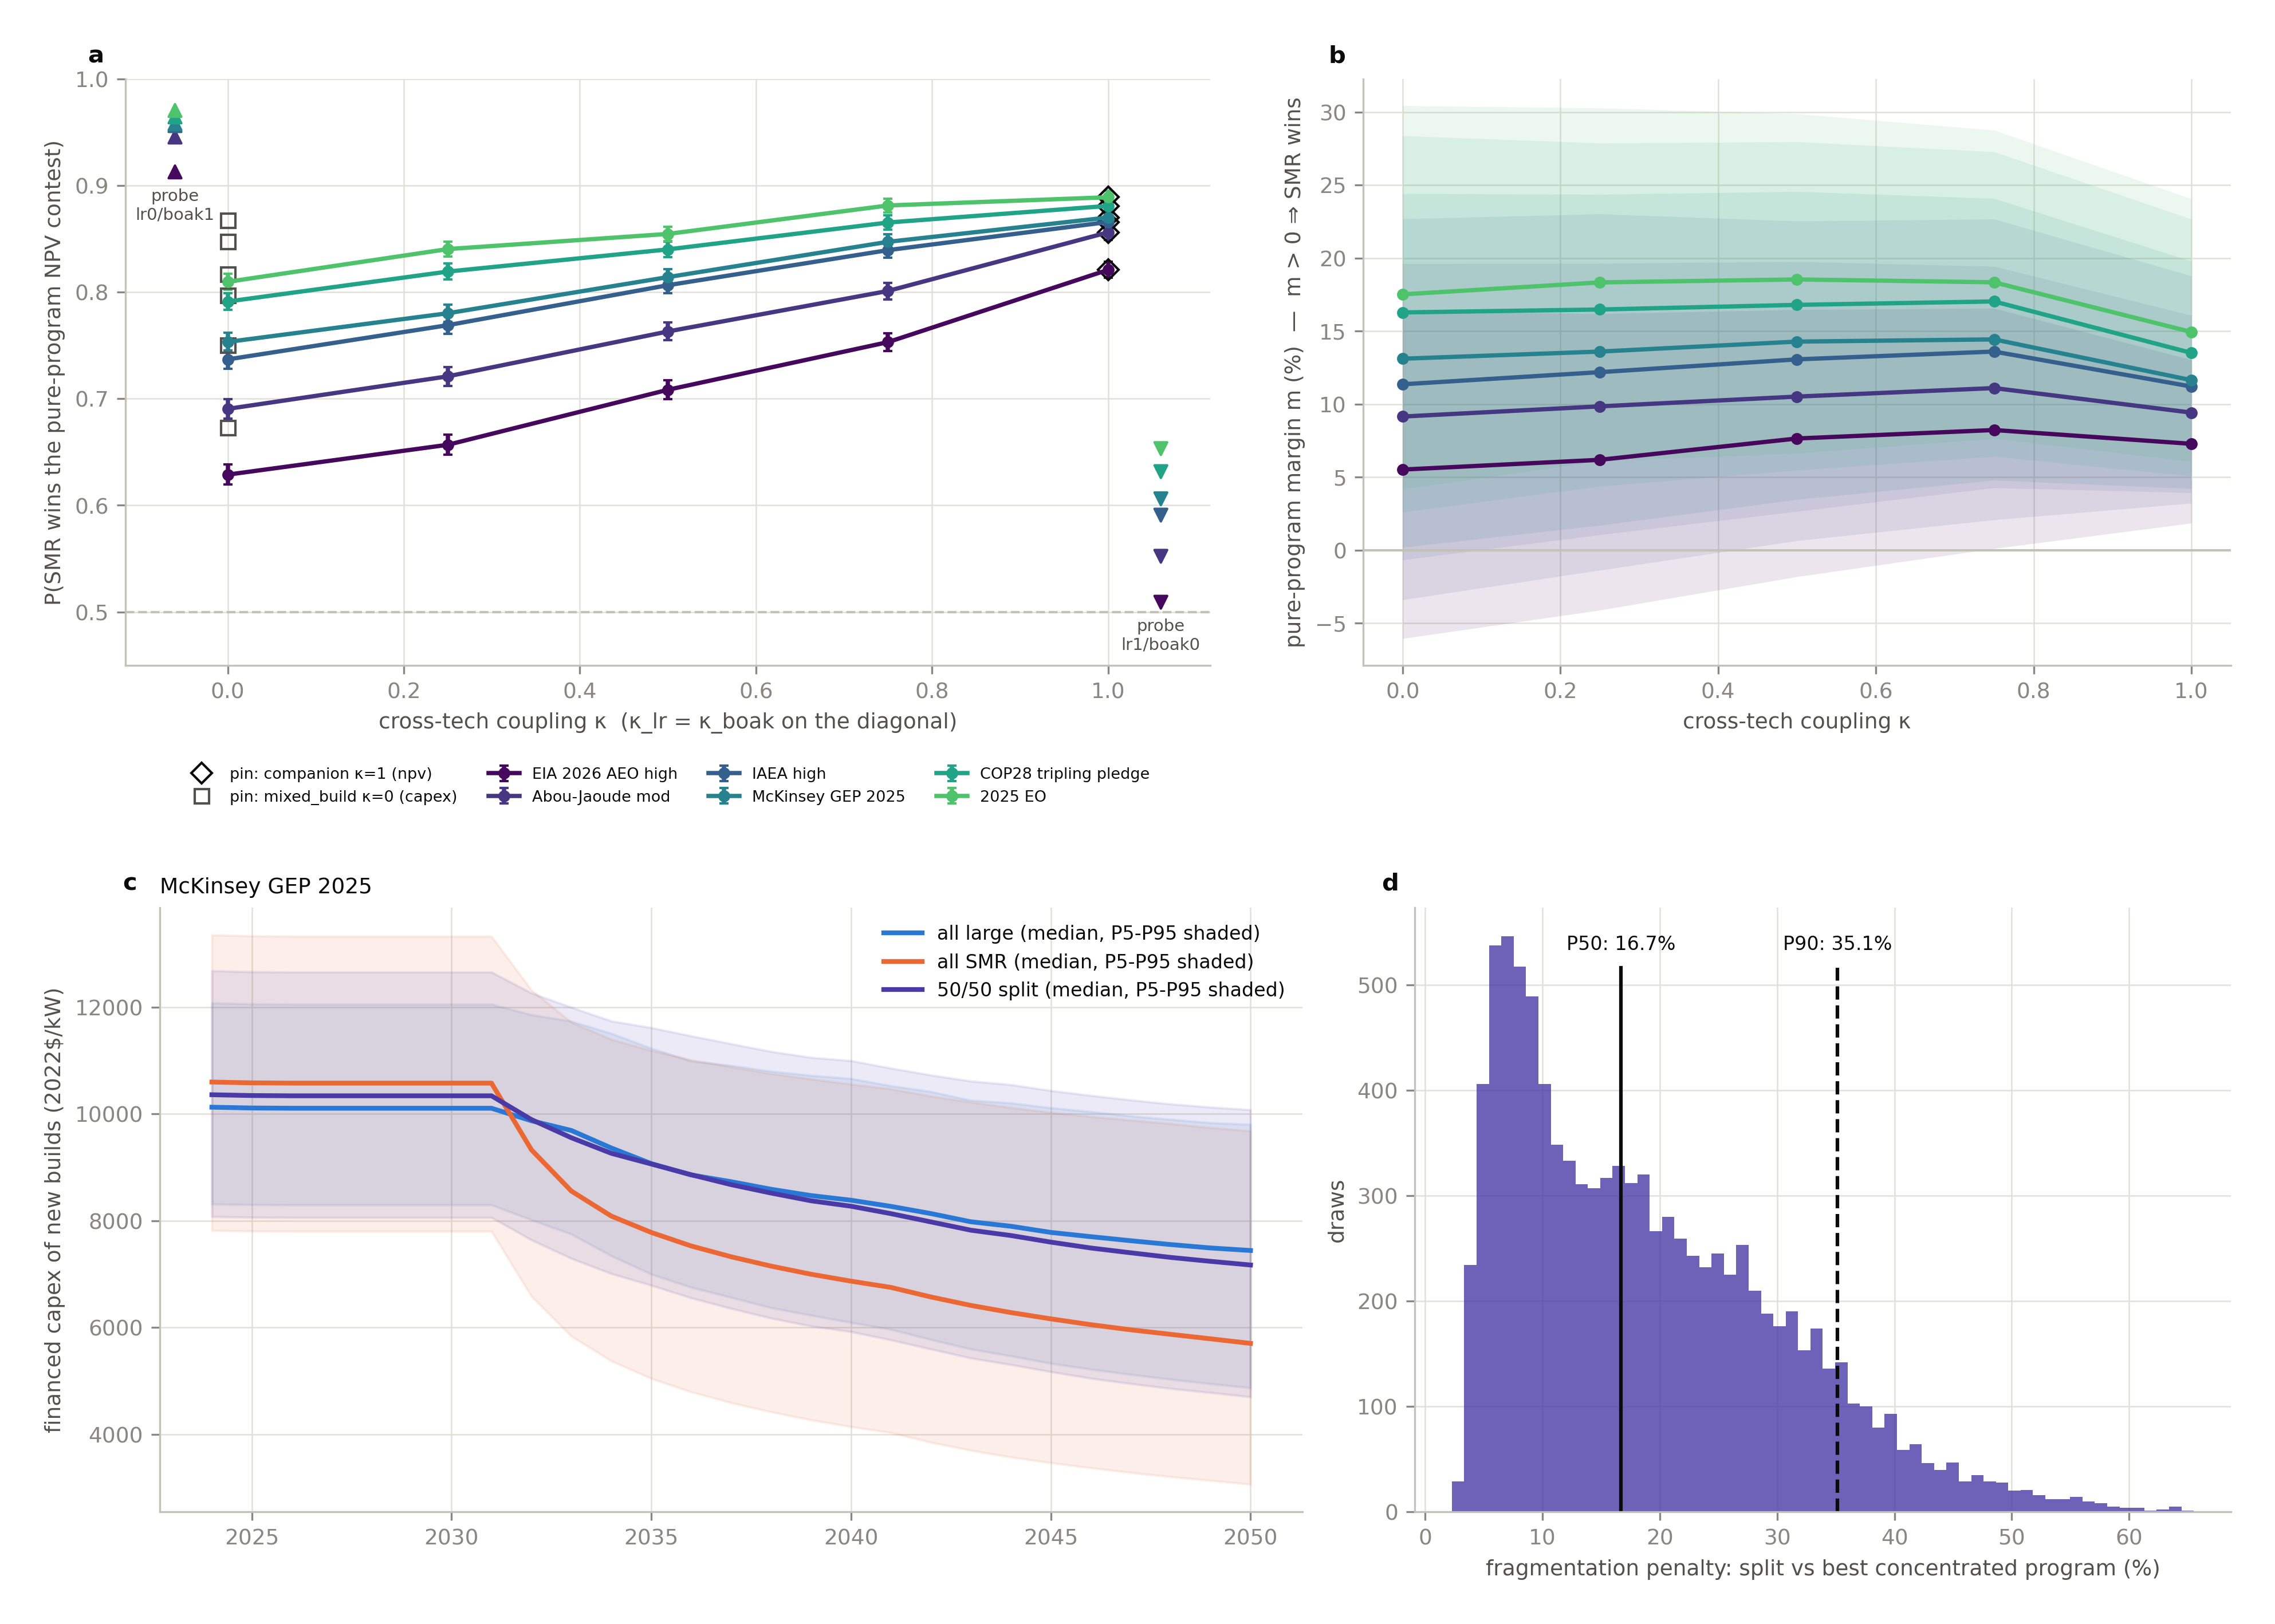

**Sources — edit the figure at its origin, not here:**

- `z-ethan\mc\figures\tc_robustness_map.png` — generated by `mc/tech_comparison.ipynb` (cell 18) from `mc/exports/mc_perdraw.npz` + the κ-grid per-draw exports; table: `mc/exports/tech_comparison/robustness_map.csv`
- `z-ethan\mc\figures\fragmentation_penalty.png` — generated by `mc/mc_cost_trajectories.ipynb` (cell 39) from in-memory MC worlds for the McKinsey schedule (the fragmentation experiment)

P(SMR cheaper), primary κ cells: min 0.503 (incl. probes), comonotone range 0.51-0.89

--- draft caption [Fig 2] ---
The 100%-SMR conditioning. (a) Probability that a 100%-SMR program is cheaper than a 100%-large
program, across schedules and across the dependence grid (kappa = how strongly the two
technologies' cost uncertainties move together). SMR is the majority winner in every primary
cell; the minimum is 0.509 at the decoupled-anchor probe. (b) The winning margin m across the
same grid (m > 0 = SMR wins; median and quantile fans). (c) Financed capex of the three program
strategies under the McKinsey schedule (medians, P5-P95 bands). (d) Fragmentation penalty: the
extra program cost of the 50/50 split, median 16.7% — splitting the program splits the learning.
The commitment is majority-optimal, not certain: large can win by ~30% in decoupled worlds, and
a 1.5x SMR optimism-bias stress breaks the claim.


In [3]:
P.compose(
    [[MC_FIG / "tc_robustness_map.png"],
     [MC_FIG / "fragmentation_penalty.png"]],
    "Fig2_smr_conditioning.png",
    letters="",  # both sources carry their final letters (a,b / c,d)
)
P.source_ref(
    (MC_FIG / "tc_robustness_map.png", "mc/tech_comparison.ipynb", "cell 18",
     "`mc/exports/mc_perdraw.npz` + the κ-grid per-draw exports; table: `mc/exports/tech_comparison/robustness_map.csv`"),
    (MC_FIG / "fragmentation_penalty.png", "mc/mc_cost_trajectories.ipynb", "cell 39",
     "in-memory MC worlds for the McKinsey schedule (the fragmentation experiment)"),
)

rm = pd.read_csv(MC_EXP / "tech_comparison" / "robustness_map.csv")
prim = rm[rm["kind"] == "primary"]
print(f"P(SMR cheaper), primary κ cells: min {rm['P_smr'].min():.3f} "
      f"(incl. probes), comonotone range {prim[prim['kappa_lr'] == 1.0]['P_smr'].min():.2f}"
      f"-{prim[prim['kappa_lr'] == 1.0]['P_smr'].max():.2f}")

P.caption("Fig 2", '''
The 100%-SMR conditioning. (a) Probability that a 100%-SMR program is cheaper than a
100%-large program, across schedules and across the dependence grid (kappa = how strongly
the two technologies' cost uncertainties move together). SMR is the majority winner in
every primary cell; the minimum is 0.509 at the decoupled-anchor probe. (b) The winning
margin m across the same grid (m > 0 = SMR wins; median and quantile fans).
(c) Financed capex of the three program strategies under the McKinsey schedule
(medians, P5-P95 bands). (d) Fragmentation penalty: the extra program cost of the
50/50 split, median 16.7% — splitting the program splits the learning. The commitment
is majority-optimal, not certain: large can win by ~30% in decoupled worlds, and a
1.5x SMR optimism-bias stress breaks the claim.
''')

## Figure 3 — The required subsidy is a bridge — in cheap worlds

**What this shows.** The paper's central object: the mandate's dual — the
yearly rental price, per kW of mandated capacity, that makes each schedule
worth building (see glossary). Panel (a): the dual over time for each
schedule, in cheap (P5), median (P50), and expensive (P95) cost worlds,
with the large-reactor comparator overlaid at P50. Panel (b): the same
duals divided by their own peak, so every case starts at 1 and we can
compare shapes. Panel (c): the average binding dual against schedule
ambition.

**How to read it.** A "bridge" subsidy should decay: high at first, near
zero once the fleet has walked down the learning curve. Panel (b) tests
exactly that. In panel (c), read left to right as more ambitious mandates.

**Key results.**
- The dual is monotone in the cost world: expensive worlds need more in
  every year, with no crossings. Mean binding duals run 70–201 (P5),
  314–390 (P50), and 610–698 (P95) in 2024\$/kW-yr; the single peak is 894
  (EO schedule, P95 world, 2031).
- In cheap worlds the bridge comes down: end-of-horizon duals are 3–19% of
  peak. Median worlds are mixed. **In P95 worlds the subsidy does not come
  down: 66–84% of peak in 2050, and no P95 case falls below half its peak
  by 2050.** Under slow learning the subsidy is not a bridge but a standing
  commitment. We give this adverse result the same prominence as the decay
  result.
- Across the ladder the P50 dual first rises (334→390 going 117→134 GW),
  then falls monotonically to 314 at 400 GW: more ambitious mandates buy
  more learning per mandated year. This is a cross-section of different
  conditional worlds, not a supply curve.

composed -> z-ethan\paper_figures\figures\Fig3_required_subsidy_bridge.png  (5941x3390 px)


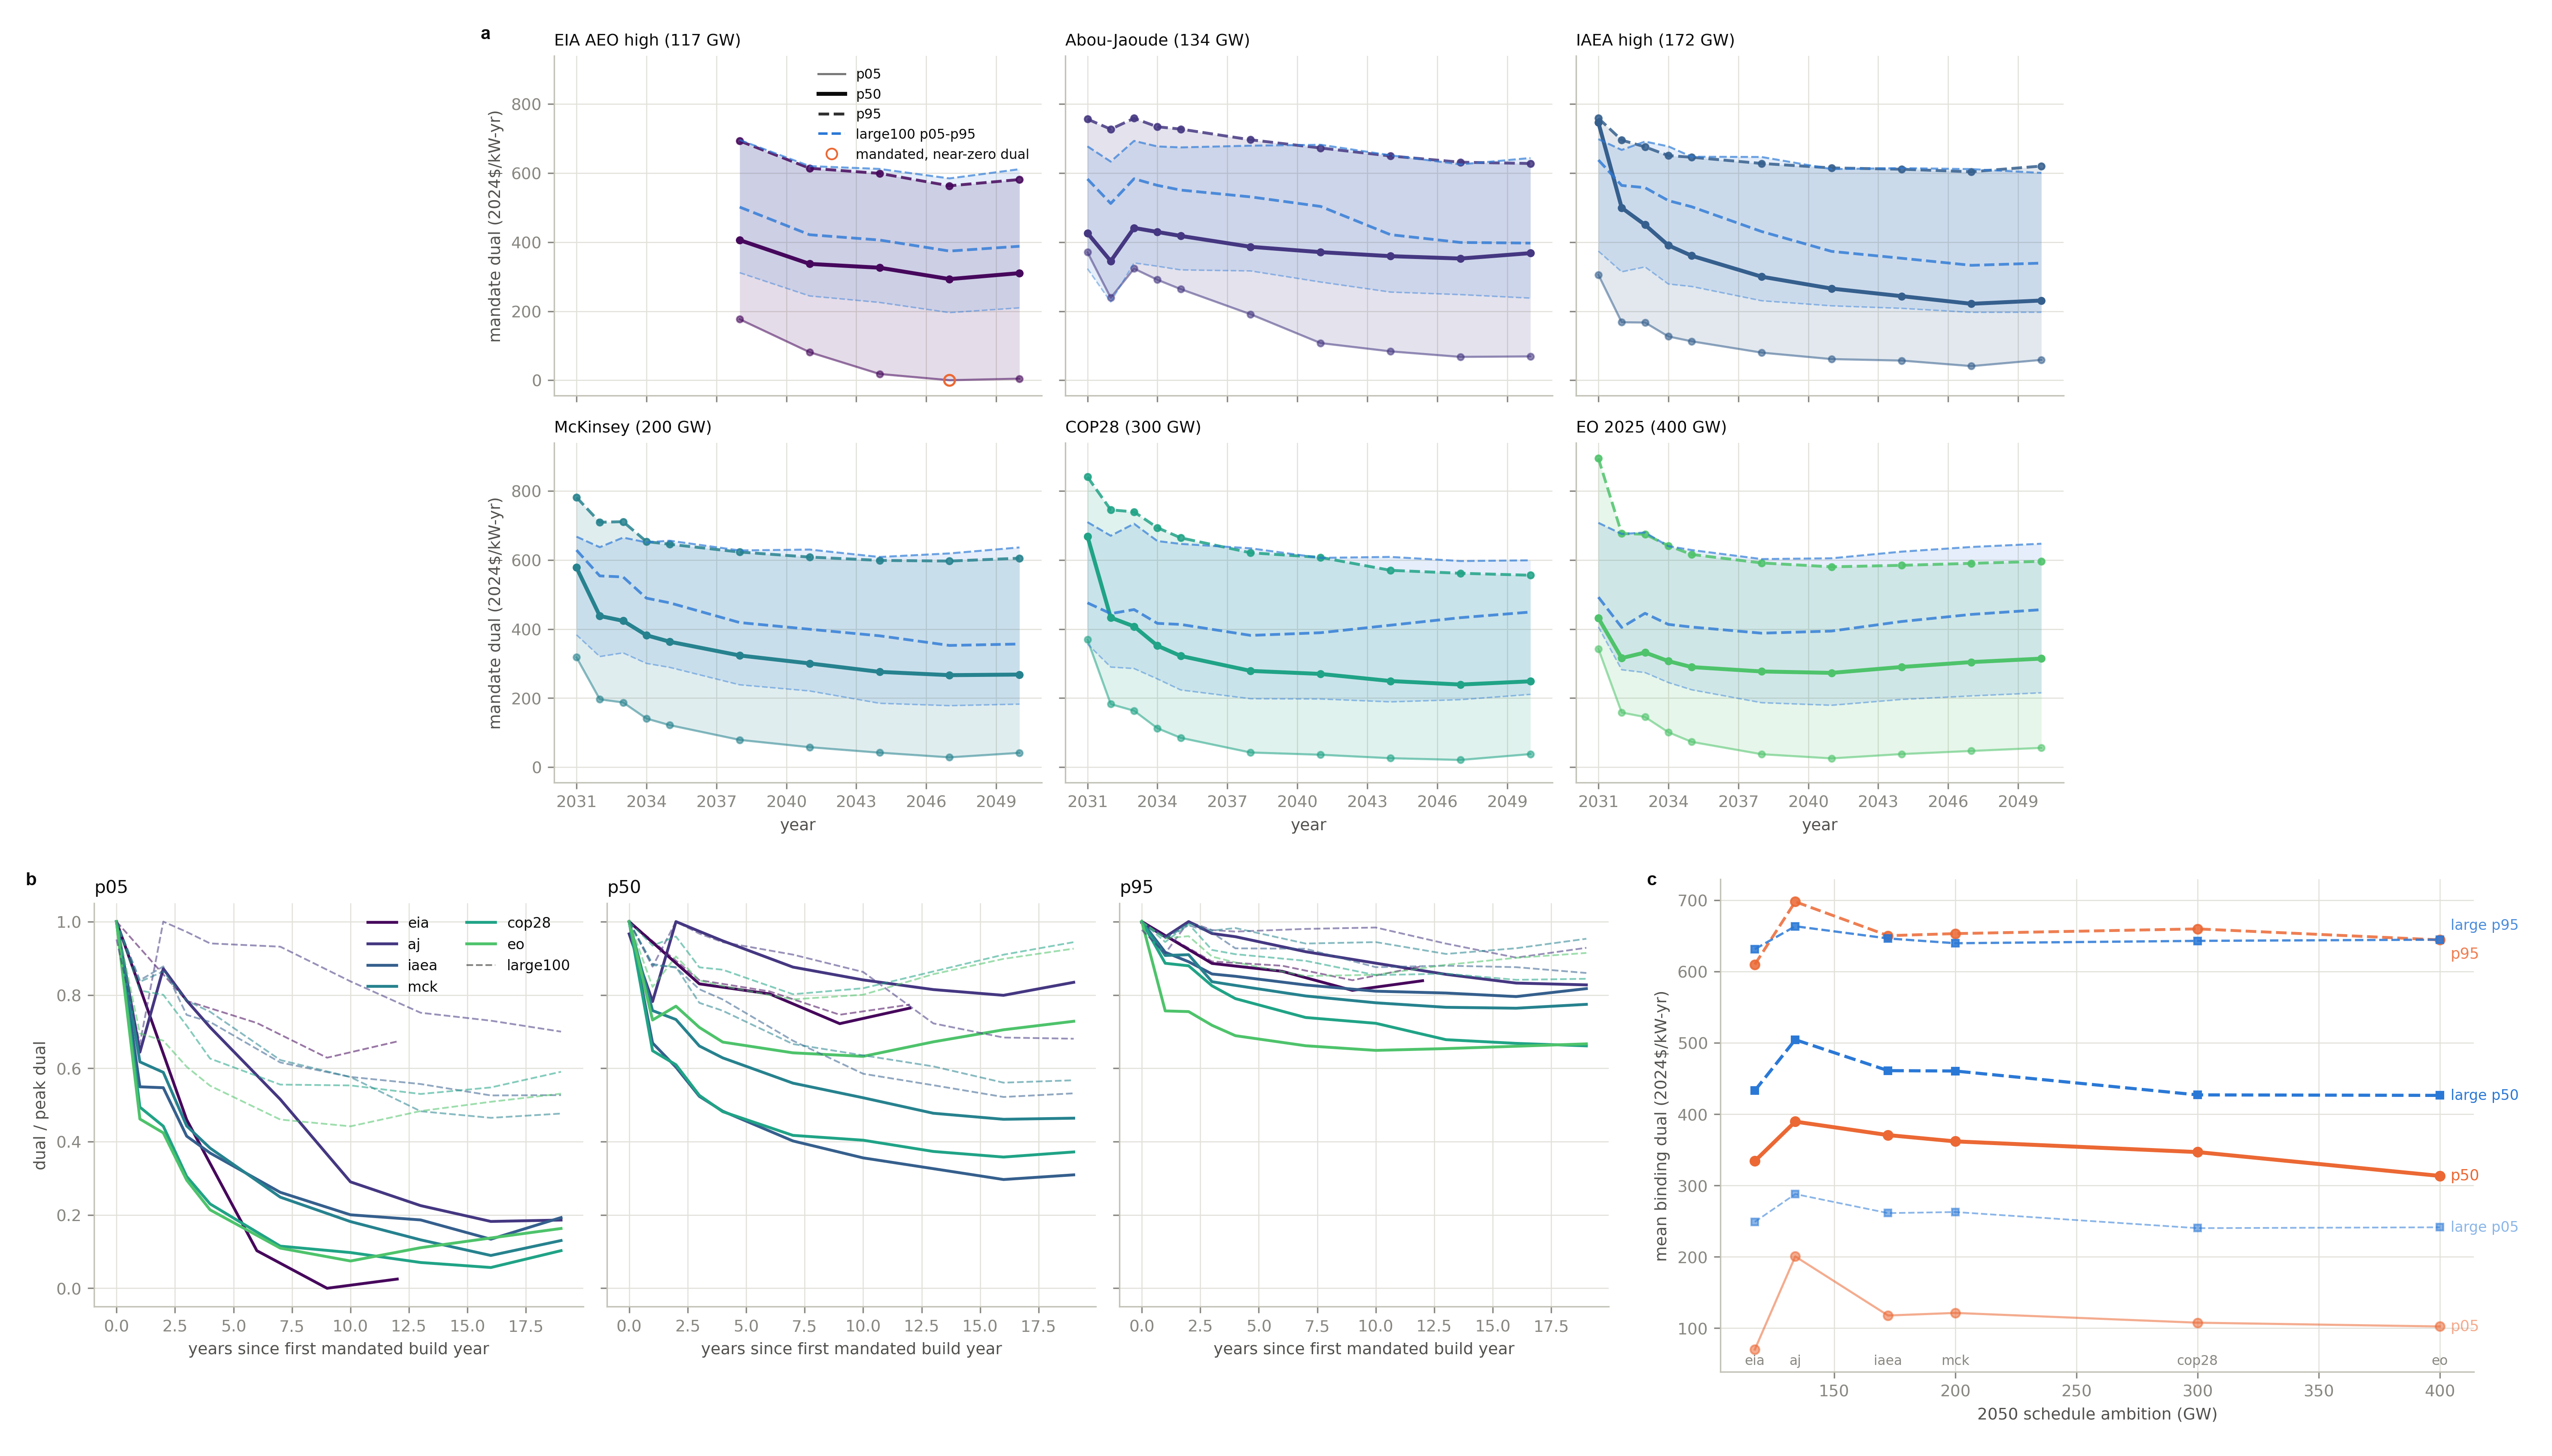

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step3_analysis\figures\f04_dual_fans.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 18) from `step3_checks/exports/duals_by_year.csv` (+ step4 checks for the large100 overlay)
- `z-ethan\step3_analysis\figures\f07_dual_shape_normalized.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 26) from same duals, normalized by each case's peak
- `z-ethan\step3_analysis\figures\f06_dual_vs_ambition.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 21) from `step3_analysis/exports/t03_dual_summary.csv`

p05: mean binding dual 70-201 2024$/kW-yr
p50: mean binding dual 314-390 2024$/kW-yr
p95: mean binding dual 610-698 2024$/kW-yr
peak dual: 894 (smr100_eo_p95, 2031)
p95 end/peak: 0.66-0.84; p95 cases below half-peak by 2050: 0 of 6

--- draft caption [Fig 3] ---
The required subsidy and its bridge shape. (a) The mandate's dual — the yearly rental price per
kW of mandated capacity (2024$) — by solve year, for each schedule in cheap (P5), median (P50),
and expensive (P95) cost worlds; large-reactor P50 comparators overlaid. Duals are monotone in
the cost world, peaking at 894 $/kW-yr (smr100_eo_p95, 2031). (b) Duals normalized by their own
peak: cheap worlds decay to 3-19% of peak; no P95 case reaches half its peak by 2050 — under
slow learning the subsidy is a standing commitment, not a bridge. (c) Mean binding dual against
ambition: the P50 level rises 117->134 GW, then falls monotonically to 400 GW. Cross-sectional,
conditional worlds; not a supply curve.


In [4]:
P.compose(
    [[S3_FIG / "f04_dual_fans.png"],
     [S3_FIG / "f07_dual_shape_normalized.png", S3_FIG / "f06_dual_vs_ambition.png"]],
    "Fig3_required_subsidy_bridge.png",
    center=True,  # row widths differ; do not leave a blank corner
)
P.source_ref(
    (S3_FIG / "f04_dual_fans.png", "step3_analysis/step3_analysis.ipynb", "cell 18",
     "`step3_checks/exports/duals_by_year.csv` (+ step4 checks for the large100 overlay)"),
    (S3_FIG / "f07_dual_shape_normalized.png", "step3_analysis/step3_analysis.ipynb", "cell 26",
     "same duals, normalized by each case's peak"),
    (S3_FIG / "f06_dual_vs_ambition.png", "step3_analysis/step3_analysis.ipynb", "cell 21",
     "`step3_analysis/exports/t03_dual_summary.csv`"),
)

t03 = pd.read_csv(S3_EXP / "t03_dual_summary.csv")
t04 = pd.read_csv(S3_EXP / "t04_bridge_metrics.csv")
smr = t03[t03["case"].str.startswith("smr100")]
for pct in ["p05", "p50", "p95"]:
    sel = smr[smr["case"].str.endswith(pct)]
    print(f"{pct}: mean binding dual {sel['mean_binding_dual_2024_kWyr'].min():.0f}"
          f"-{sel['mean_binding_dual_2024_kWyr'].max():.0f} 2024$/kW-yr")
pk = t03.loc[t03["peak_dual_2024_kWyr"].idxmax()]
print(f"peak dual: {pk['peak_dual_2024_kWyr']:.0f} ({pk['case']}, {int(pk['peak_year'])})")
p95 = t04[t04["case"].str.startswith("smr100") & t04["case"].str.endswith("p95")]
n_below = int((p95["first_year_below_half_peak"] <= 2050).sum())
print(f"p95 end/peak: {p95['end_over_peak'].min():.2f}-{p95['end_over_peak'].max():.2f}; "
      f"p95 cases below half-peak by 2050: {n_below} of {len(p95)}")

P.caption("Fig 3", f'''
The required subsidy and its bridge shape. (a) The mandate's dual — the yearly rental
price per kW of mandated capacity (2024$) — by solve year, for each schedule in cheap
(P5), median (P50), and expensive (P95) cost worlds; large-reactor P50 comparators
overlaid. Duals are monotone in the cost world, peaking at
{pk['peak_dual_2024_kWyr']:.0f} $/kW-yr ({pk['case']}, {int(pk['peak_year'])}).
(b) Duals normalized by their own peak: cheap worlds decay to 3-19% of peak; no P95
case reaches half its peak by 2050 — under slow learning the subsidy is a standing
commitment, not a bridge. (c) Mean binding dual against ambition: the P50 level rises
117->134 GW, then falls monotonically to 400 GW. Cross-sectional, conditional worlds;
not a supply curve.
''')

## Figure 4 — Required tax-credit rates and the instrument menu

**What this shows.** The dual is a model price. This figure translates it
into the actual US policy instrument and then prices the alternatives.
Panel (a): the required investment tax credit (ITC) rate, by year and case,
on the **model credit convention** (i_model: the fin_mult inversion plus
the 10% monetization haircut; the placed-in-service overnight-cost-only
conversion i_pis = i_model x ccmult is exported per year). The shaded band
marks the current 48E credit range (30–50%); the line at 100% marks where
an ITC alone cannot deliver. Panel (b): the **subsidy instrument menu** —
each instrument's net-of-tax present-value cost as a multiple of the
minimum-cost floor (a flat dollar-per-MW payment at commissioning,
elective pay), per case.

**How to read it.** Rates are per-region requirements; the headline is the
maximum building region. Where a line sits above the 48E band, current law
is not enough. Where it crosses 100%, no credit percentage can close the
gap. In panel (b), distance above 1.0 is money an instrument wastes
relative to the floor; the mandate and the commitment bound can sit below
1.0 because compliance is compelled and commitment pays only each
vintage's foresight value.

**Key results.** Median-world required rates average 0.59–0.74 across
schedules — 2.0–2.5 times the current base credit. Expensive worlds need
2.7–3.1 times; on the headline convention only 5 of 329 rated case-years
exceed 100% (the i_pis conversion exceeds 100% in 82). The uniform
percentage credit costs 1.17–1.25x the floor everywhere — the ~10%
monetization haircut plus a 5–13% uniform-rate oversubsidy, both
removable: an elective-pay dollar-per-MW credit attains the floor. The
capacity-standard mandate runs 0.29–1.18x the floor for the SMR program
but 1.0–6.3x for the large-reactor arm, where the pre-existing fleet's
rent dominates.

Two legal inputs are still open and are flagged `[LEGAL]` in the paper: the
monetization haircut size, and the depreciation recovery class. Both move
every rate in panel (a) by a known formula; neither changes the shape.

composed -> z-ethan\paper_figures\figures\Fig4_required_itc_and_menu.png  (3822x3423 px)


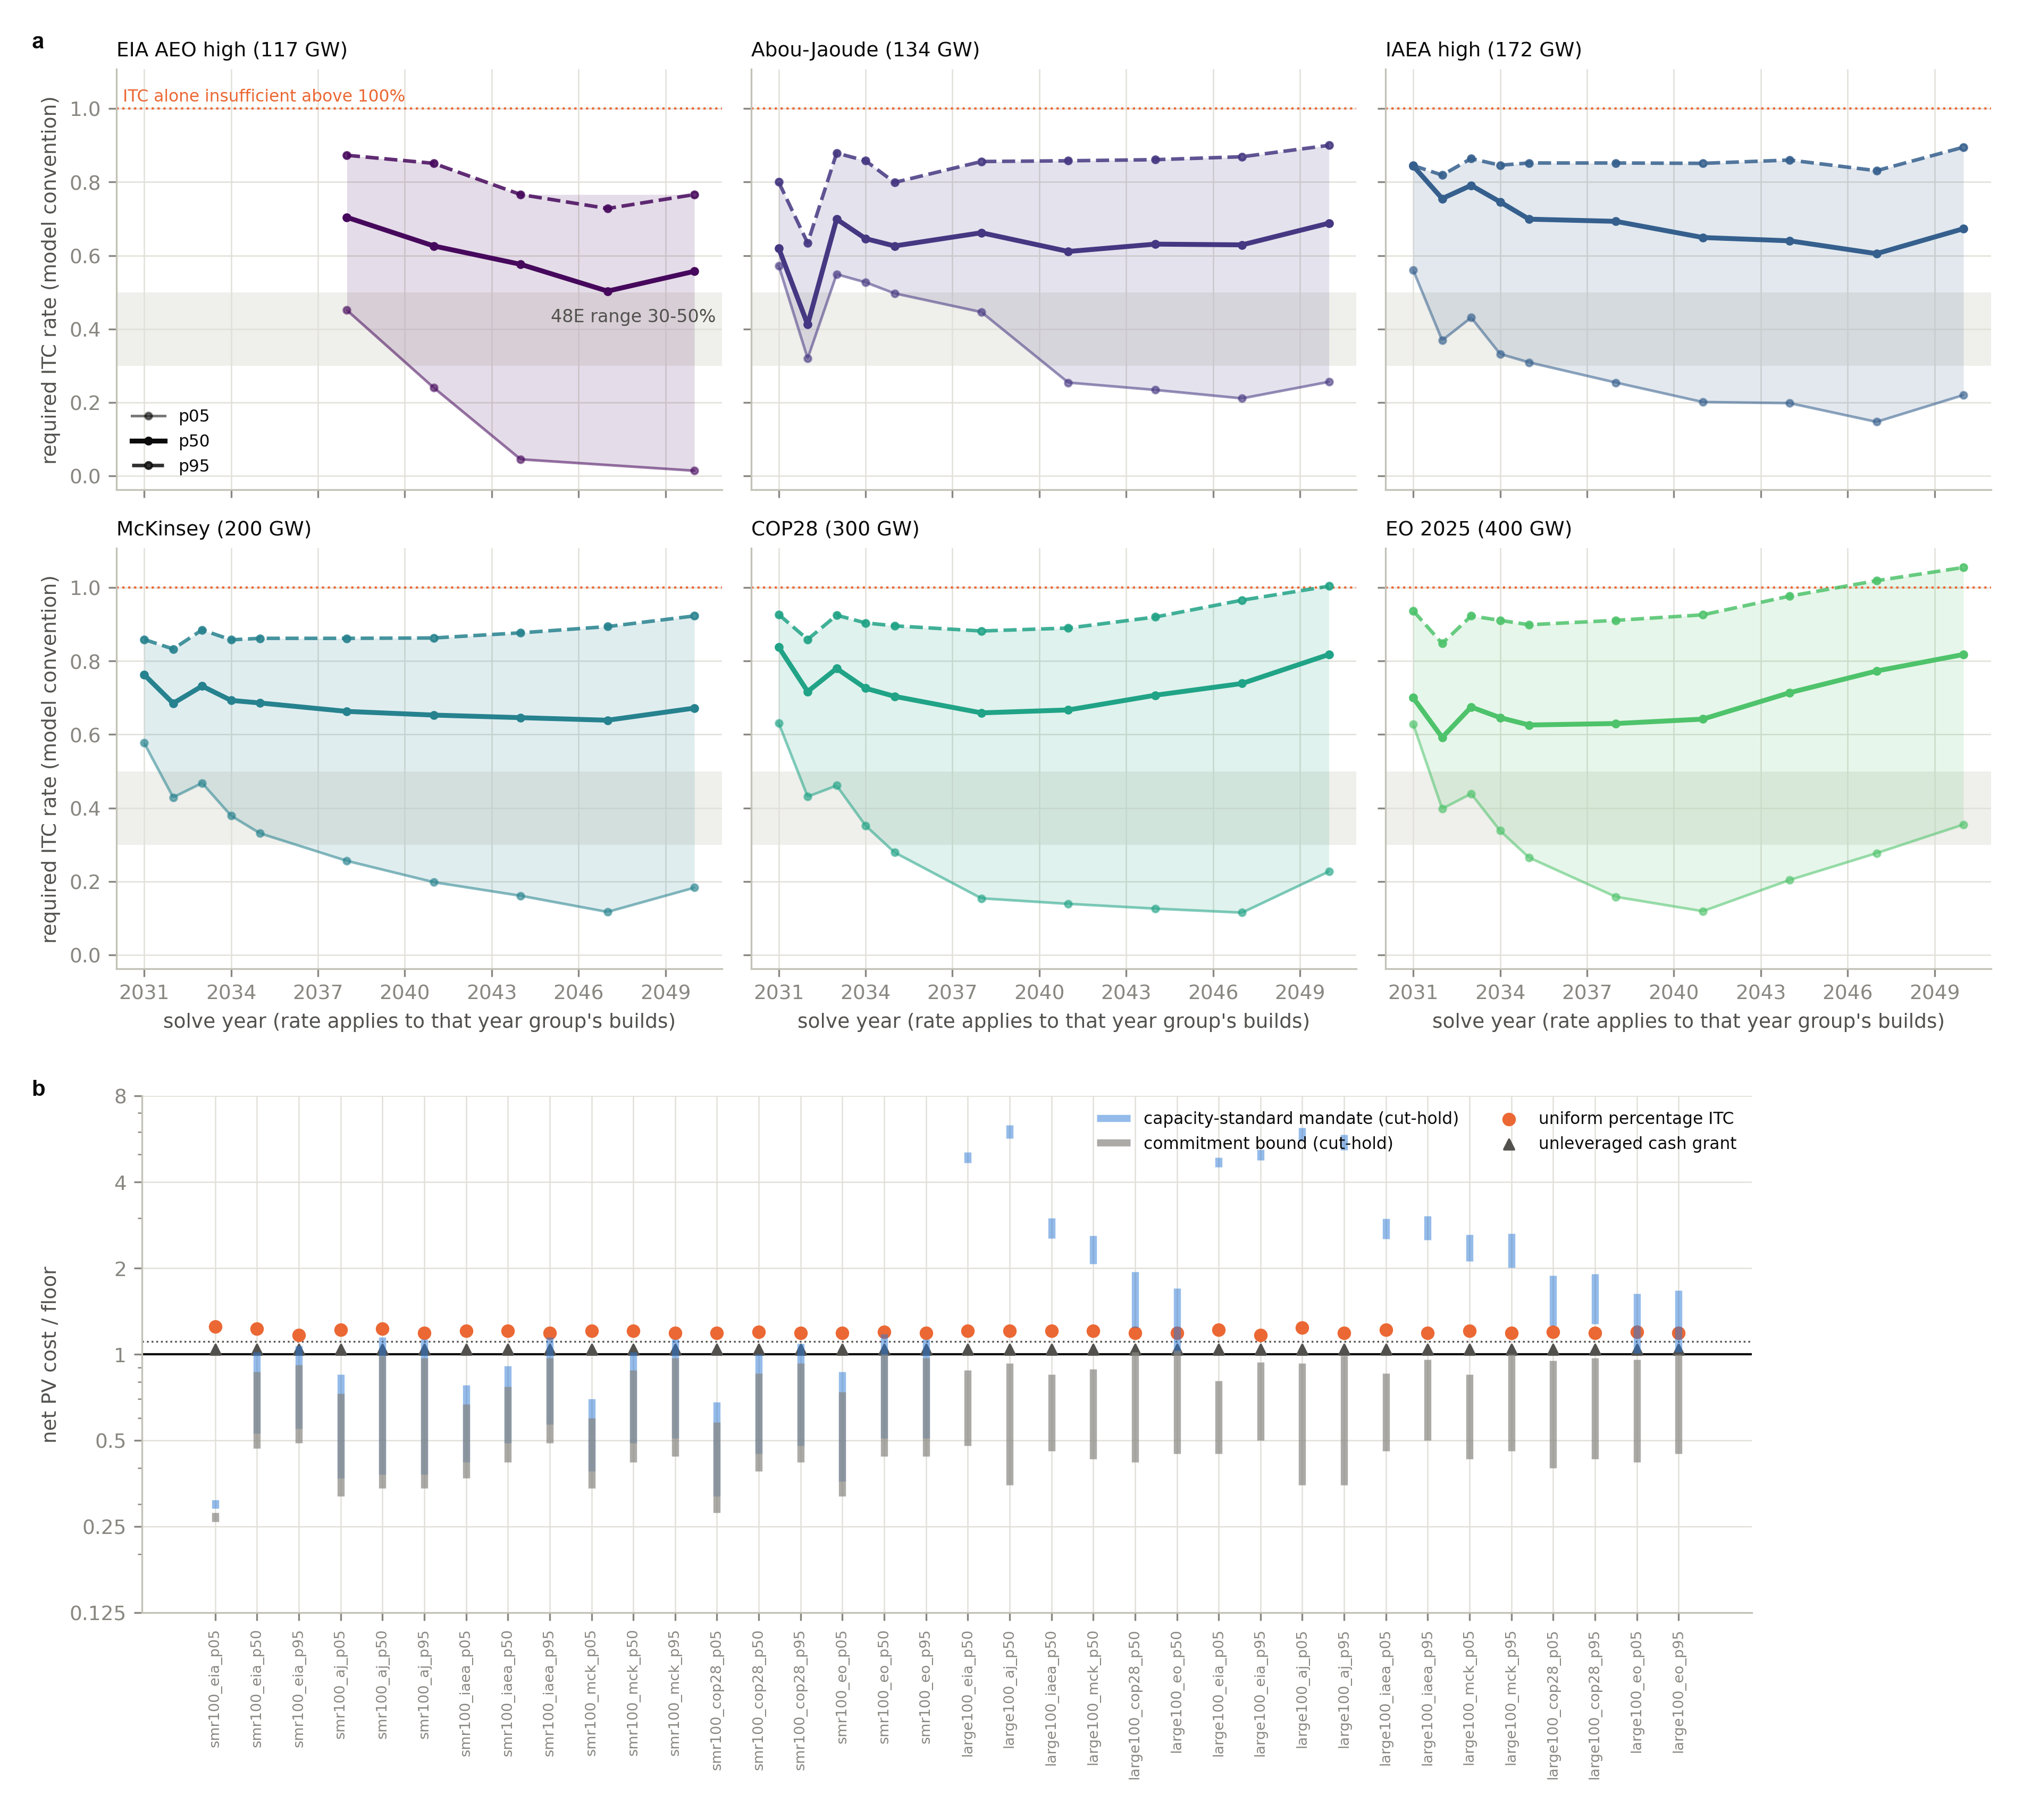

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step3_analysis\figures\f13_required_itc.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 40) from `step3_analysis/exports/t09_required_itc.csv` (model convention, regenerated 2026-08-18)
- `z-ethan\step3_analysis\figures\f16_instrument_menu.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell t18cd001) from `t18_instrument_menu.csv` (from t13 + t17)

p50 required rate (model convention), schedule averages: 0.59-0.74 (= 2.0x-2.5x the 30% base 48E credit)
case-years over 100%: 5 of 329 on the model convention; 82 on the placed-in-service OCC-only conversion
uniform ITC vs floor: 1.17-1.25x

--- draft caption [Fig 4] ---
Required ITC rates and the instrument menu. (a) The required investment-tax-credit rate by solve
year on the model credit convention (fin_mult inversion + 10% monetization haircut; the placed-
in-service overnight-cost-only conversion is exported per year), P50 lines with P5-P95 whiskers;
band = current 48E range (30-50%), line = 100%. Median-world schedule averages run 0.59-0.74
(2.0-2.5x the base credit); 5 of 329 rated case-years exceed 100% (82 on the placed-in-service
conversion). (b) The subsidy instrument menu: net-of-tax PV cost per instrument as a multiple of
the minimum-cost floor (flat $/MW at commissioning, elective pay), per case; the uniform
percentage credit costs 1.17-1.25x the floor (haircut + uniform

In [5]:
P.compose(
    [[S3_FIG / "f13_required_itc.png"],
     [S3_FIG / "f16_instrument_menu.png"]],
    "Fig4_required_itc_and_menu.png",
    letters="ab",
)
P.source_ref(
    (S3_FIG / "f13_required_itc.png", "step3_analysis/step3_analysis.ipynb", "cell 40",
     "`step3_analysis/exports/t09_required_itc.csv` (model convention, regenerated 2026-08-18)"),
    (S3_FIG / "f16_instrument_menu.png", "step3_analysis/step3_analysis.ipynb", "cell t18cd001",
     "`t18_instrument_menu.csv` (from t13 + t17)"),
)

t09 = pd.read_csv(S3_EXP / "t09_required_itc.csv")
r = t09[t09["status"] == "rate"]
smr_r = r[r["case"].str.startswith("smr100")]
p50 = smr_r[smr_r["case"].str.endswith("p50")].groupby("case")["i_model_headline"].mean()
print(f"p50 required rate (model convention), schedule averages: {p50.min():.2f}-{p50.max():.2f} "
      f"(= {p50.min()/0.30:.1f}x-{p50.max()/0.30:.1f}x the 30% base 48E credit)")
ded = r[~r["case"].str.endswith("_eq")]
n100 = int((ded["i_model_headline"] > 1.0).sum())
n100p = int((ded["i_pis_headline"] > 1.0).sum())
print(f"case-years over 100%: {n100} of {len(ded)} on the model convention; "
      f"{n100p} on the placed-in-service OCC-only conversion")

t18 = pd.read_csv(S3_EXP / "t18_instrument_menu.csv")
m18 = t18[~t18["case"].str.endswith("_eq")]
print(f"uniform ITC vs floor: {m18['uniform_itc'].min():.2f}-{m18['uniform_itc'].max():.2f}x")

P.caption("Fig 4", f'''
Required ITC rates and the instrument menu. (a) The required investment-tax-credit rate by
solve year on the model credit convention (fin_mult inversion + 10% monetization haircut;
the placed-in-service overnight-cost-only conversion is exported per year), P50 lines with
P5-P95 whiskers; band = current 48E range (30-50%), line = 100%. Median-world schedule
averages run {p50.min():.2f}-{p50.max():.2f} ({p50.min()/0.30:.1f}-{p50.max()/0.30:.1f}x
the base credit); {n100} of {len(ded)} rated case-years exceed 100% ({n100p} on the
placed-in-service conversion). (b) The subsidy instrument menu: net-of-tax PV cost per
instrument as a multiple of the minimum-cost floor (flat $/MW at commissioning, elective
pay), per case; the uniform percentage credit costs
{m18['uniform_itc'].min():.2f}-{m18['uniform_itc'].max():.2f}x the floor (haircut +
uniform-rate oversubsidy, both removable), the capacity-standard mandate and the
commitment bound bracket it on both sides.
Rates are final up to two flagged legal inputs (monetization haircut; depreciation class).
''')

## Figure 5 — What it would take for the ATB cost trajectories to happen

**What this shows.** The NREL Annual Technology Baseline (ATB) publishes
nuclear cost trajectories that many models consume as inputs. We invert the
question: which learning worlds, and how much deployment, would make those
trajectories come true? Panel (a): the deployment each ATB trajectory
requires, as a function of the learning rate, with the ATB's own paired
deployments marked. Panel (b): maps of the parameter worlds that come
within \$250/kW of each ATB trajectory ("feasible sets"), for large
reactors and SMR.

**How to read it.** In panel (a), compare each curve against its marked
pairing: if the curve sits far above the mark, the ATB trajectory assumes
more learning than its own deployment can deliver. In panel (b), small
colored regions mean few defensible worlds reproduce the trajectory.

**Key results.** Worlds that reproduce an ATB trajectory at its paired
deployment are 0.03–1.7% of the support-restricted grid, and the best fits
for the moderate and advanced trajectories need firm-level learning rates
of 12.5–13.5% against the source study's own 9.5% (the conservative
trajectories need 17.5–20%).
The large-conservative trajectory (a 23% decline on 12 GW) is reproduced
nowhere in the sampled support. Read as required deployment, the ATB pairings
understate what their own cost declines demand by a factor of about 2–3.4
(for example, large-advanced needs about 677 GW against a 199 GW pairing).
Every model consuming ATB nuclear costs inherits these implicit bets.
This inversion uses about 0.79 million sampled worlds per trajectory and
zero ReEDS runs.

composed -> z-ethan\paper_figures\figures\Fig5_atb_inversion.png  (7872x4409 px)


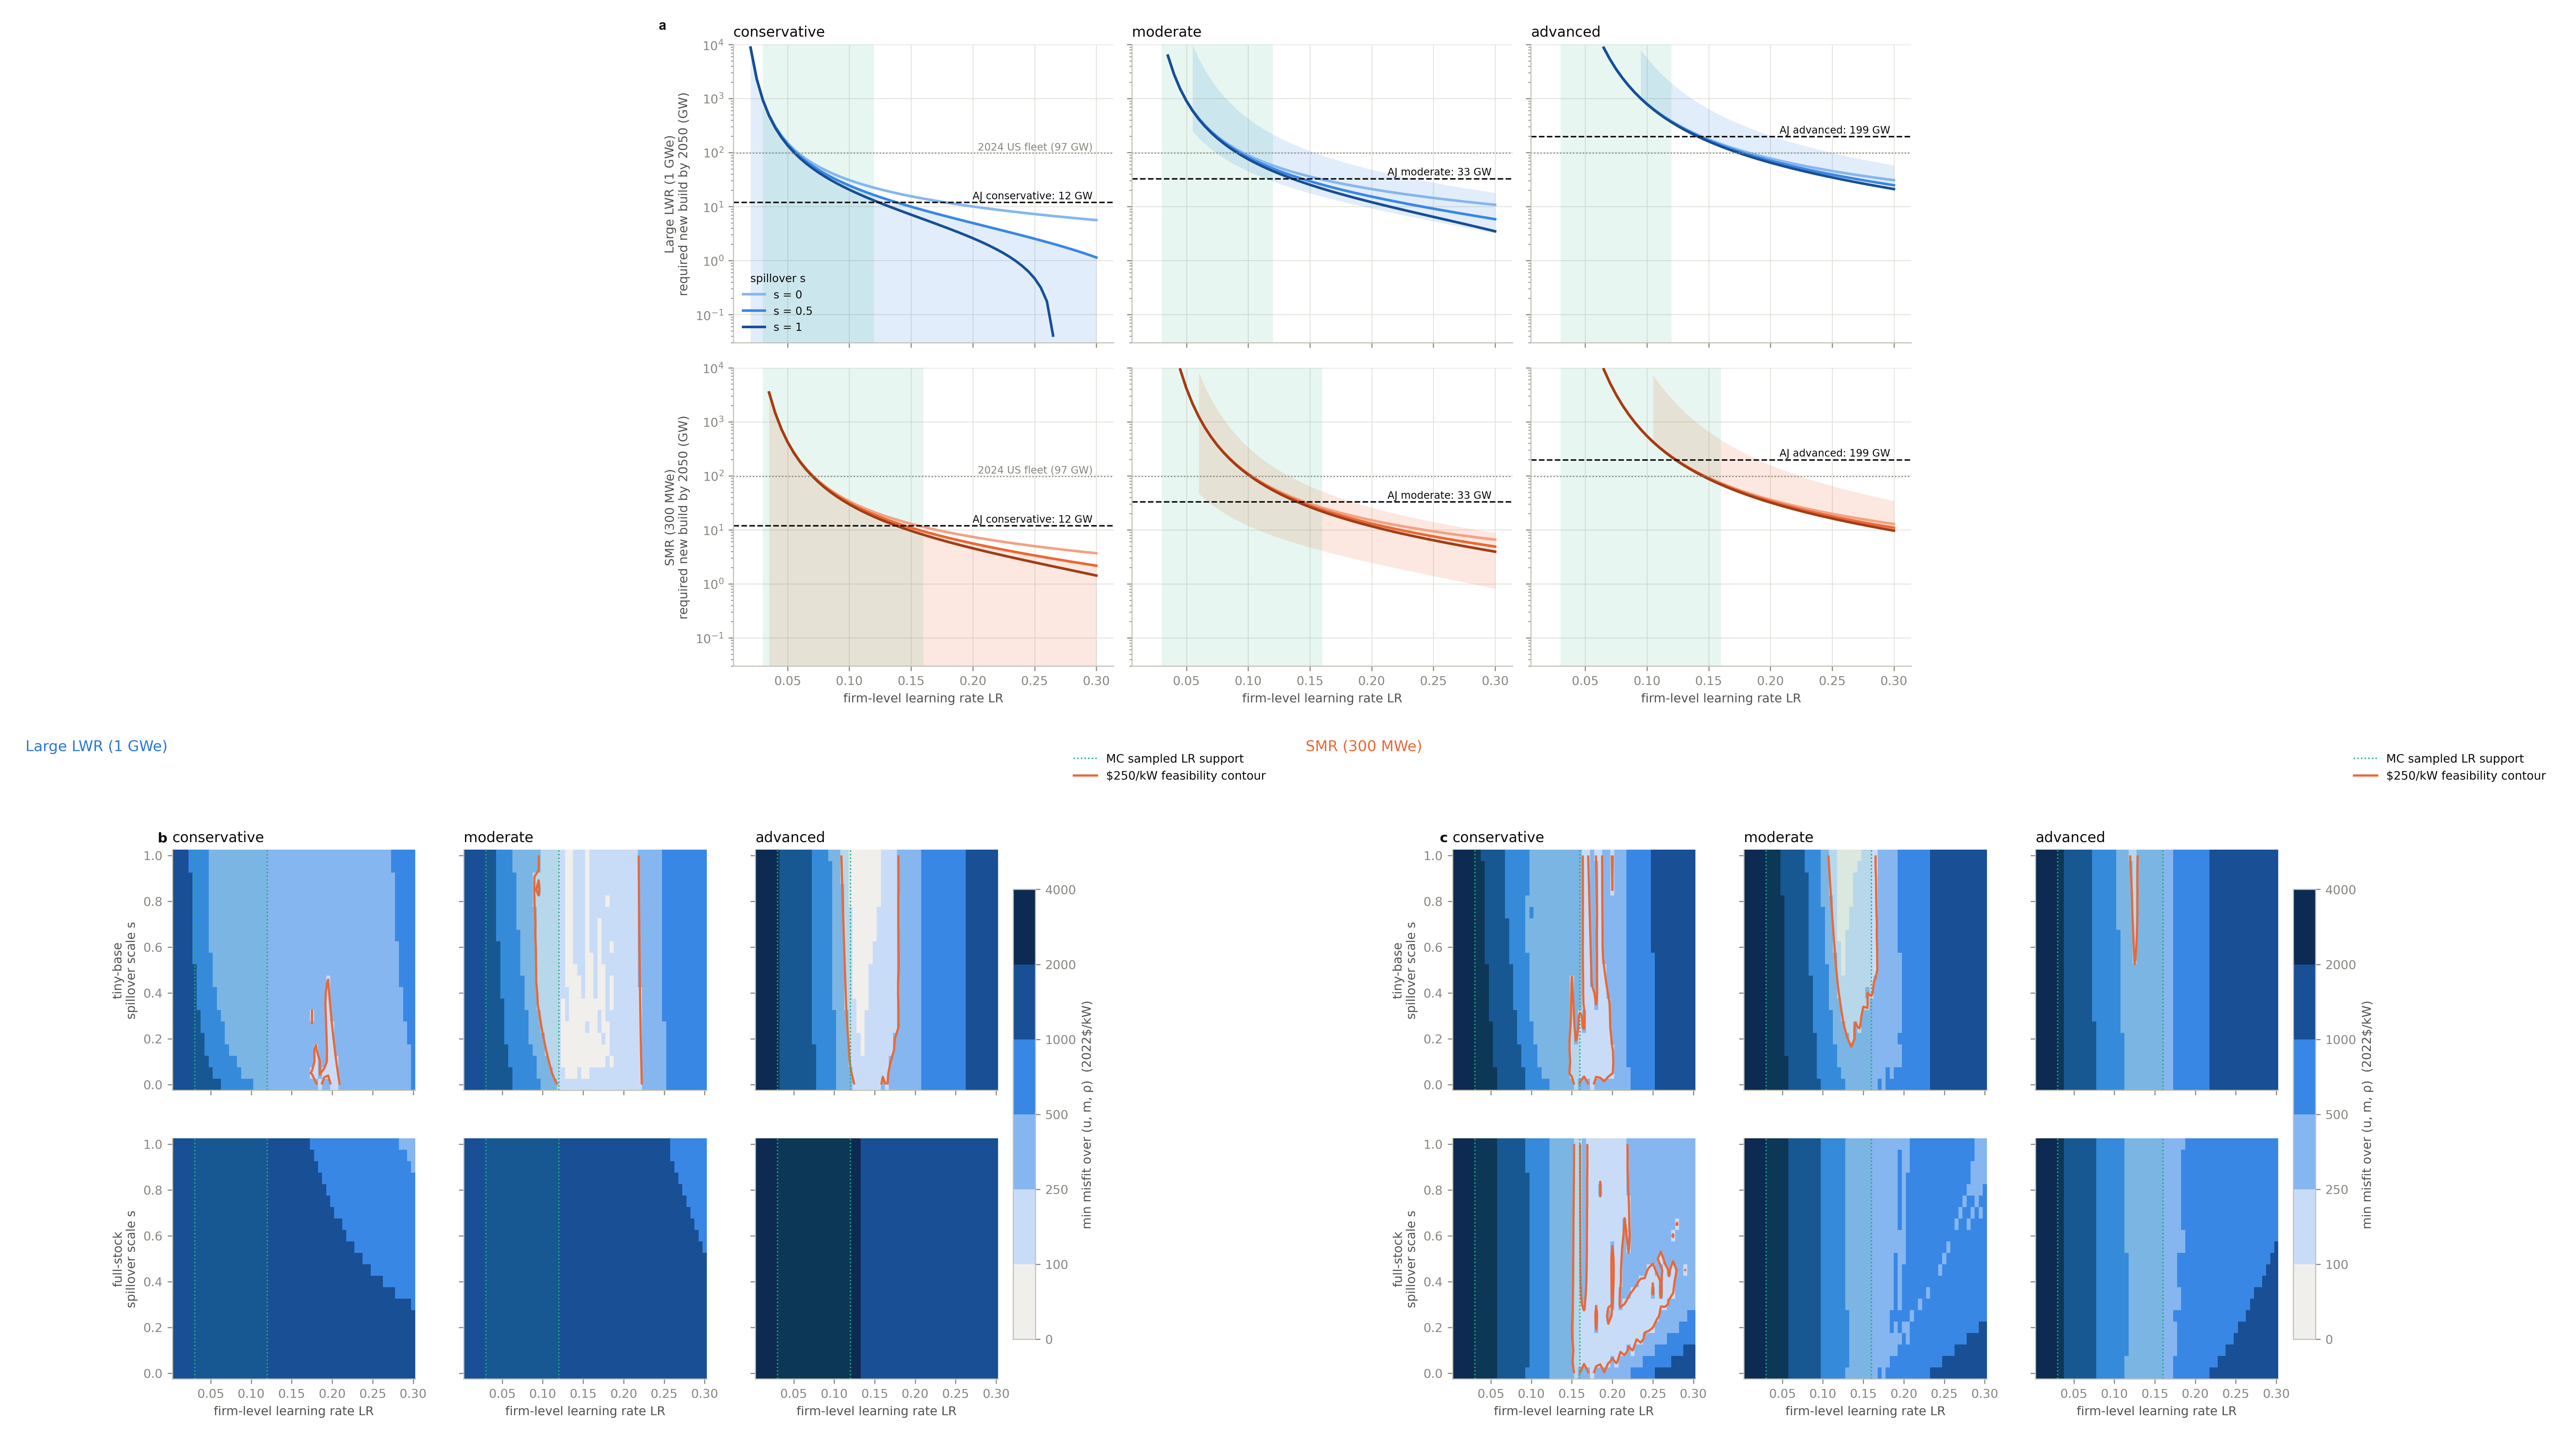

**Sources — edit the figure at its origin, not here:**

- `z-ethan\mc\figures\atb_required_deployment_vs_lr.png` — generated by `mc/atb_parameter_space.ipynb` (cell 22) from the grid inversion (~0.79M worlds/trajectory); anchors: `mc/exports/atb/required_deployment_anchors.csv`
- `z-ethan\mc\figures\atb_feasible_maps_large.png` — generated by `mc/atb_parameter_space.ipynb` (cell 15) from per-world misfit grids (`mc/exports/atb/atb_misfit_perworld.npz`), $250/kW tolerance
- `z-ethan\mc\figures\atb_feasible_maps_smr.png` — generated by `mc/atb_parameter_space.ipynb` (cell 15) from same misfit grids, SMR trajectories

 tech     scenario  min_misfit_$kW  share_grid_<=$100  share_support_<=$100  share_grid_<=$250  share_support_<=$250  share_grid_<=$500  share_support_<=$500
large conservative           231.9             0.0000                0.0000             0.0005                0.0000             0.0887                0.0594
large     moderate            78.9             0.0011                0.0000             0.0519                0.0174             0.1410                0.0922
large     advanced            38.2             0.0017                0.0001             0.0249                0.0045             0.1073                0.0384
  smr conservative           208.0             0.0000                0.0000             0.0058                0.0032             0.1174                0.0856
  smr     moderate            71.9             0.0002                0.0003             0.0039                0.0086             0.0463                0.0747
  smr     advanced           213.6             0.000

In [6]:
P.compose(
    [[MC_FIG / "atb_required_deployment_vs_lr.png"],
     [MC_FIG / "atb_feasible_maps_large.png", MC_FIG / "atb_feasible_maps_smr.png"]],
    "Fig5_atb_inversion.png",
    letters="a",   # the two feasible-map sources carry b/c themselves
    center=True,   # row widths differ; do not leave a blank corner
)
P.source_ref(
    (MC_FIG / "atb_required_deployment_vs_lr.png", "mc/atb_parameter_space.ipynb", "cell 22",
     "the grid inversion (~0.79M worlds/trajectory); anchors: `mc/exports/atb/required_deployment_anchors.csv`"),
    (MC_FIG / "atb_feasible_maps_large.png", "mc/atb_parameter_space.ipynb", "cell 15",
     "per-world misfit grids (`mc/exports/atb/atb_misfit_perworld.npz`), $250/kW tolerance"),
    (MC_FIG / "atb_feasible_maps_smr.png", "mc/atb_parameter_space.ipynb", "cell 15",
     "same misfit grids, SMR trajectories"),
)

fs = pd.read_csv(MC_EXP / "atb" / "feasible_share.csv")
print(fs.to_string(index=False))

P.caption("Fig 5", '''
What the ATB nuclear cost trajectories require. (a) Deployment required to reproduce each
ATB trajectory as a function of the learning rate, with the ATB's own paired deployment
marked: at the source study's parameters the pairings understate required deployment by
~2-3.4x. (b, c) Feasible-set maps for large reactors (b) and SMR (c): parameter worlds
within $250/kW of each trajectory at its paired deployment cover 0.03-1.7% of the
support-restricted grid; the large-conservative trajectory clears the tolerance nowhere.
Grid inversion over ~0.79M worlds per trajectory; no ReEDS runs.
''')

## Figure 6 — Robustness across market worlds

**What this shows.** Do the headline results depend on our base market
assumptions? We re-ran 18 cases under six market sensitivities (gas price
high/low, high-electrification demand, renewable costs cheap/dear, and a
transmission-limited world): 108 runs, all output checks green. Panel (a):
for every case × market world, does the bridge shape survive? Panel (b):
the dual paths for the ladder's end schedules, overlaid across market
worlds. Panel (c): the large-reactor comparator against the SMR program,
by cost-world percentile.

**How to read it.** Panel (a) is pass/fail: a cell "survives" when the case
keeps its decay class **or** its end-over-peak ratio moves by at most 0.15
(the ratified tolerance for classifier-edge flips: the class is stable in
105 of 108 cells, the ratio moves ≤ 0.15 in 96 of 108, and the three class
flips all sit within 0.02 of the 0.5 decay boundary).
In panel (b), the spread across colored lines is what market conditions do
to the subsidy level. Panel (c) compares technologies at the same
percentile.

**Key results.**
- The bridge shape survives in **108 of 108** cells, and no market world
  unbinds a mandate. The expensive-world non-decay is generic, not a
  base-world artifact.
- The ambition ladder's fiscal ordering survives (Kendall τ ≥ 0.867 in
  every cell against base, mean 0.993).
- Only the level moves, and it moves as economics predicts: median dual
  −27% under high gas prices, +18% under low, −8% under high demand,
  +9%/−10% under cheap/dear renewables, −5% transmission-limited.
- The large-reactor premium is not a constant. Large needs 1.4–3.5× the
  SMR dual in cheap worlds, 1.23–1.36× at the median — but at P95 the two
  technologies reach parity (0.95–1.02×): in expensive worlds both need
  the same subsidy.

composed -> z-ethan\paper_figures\figures\Fig6_robustness.png  (5551x4371 px)


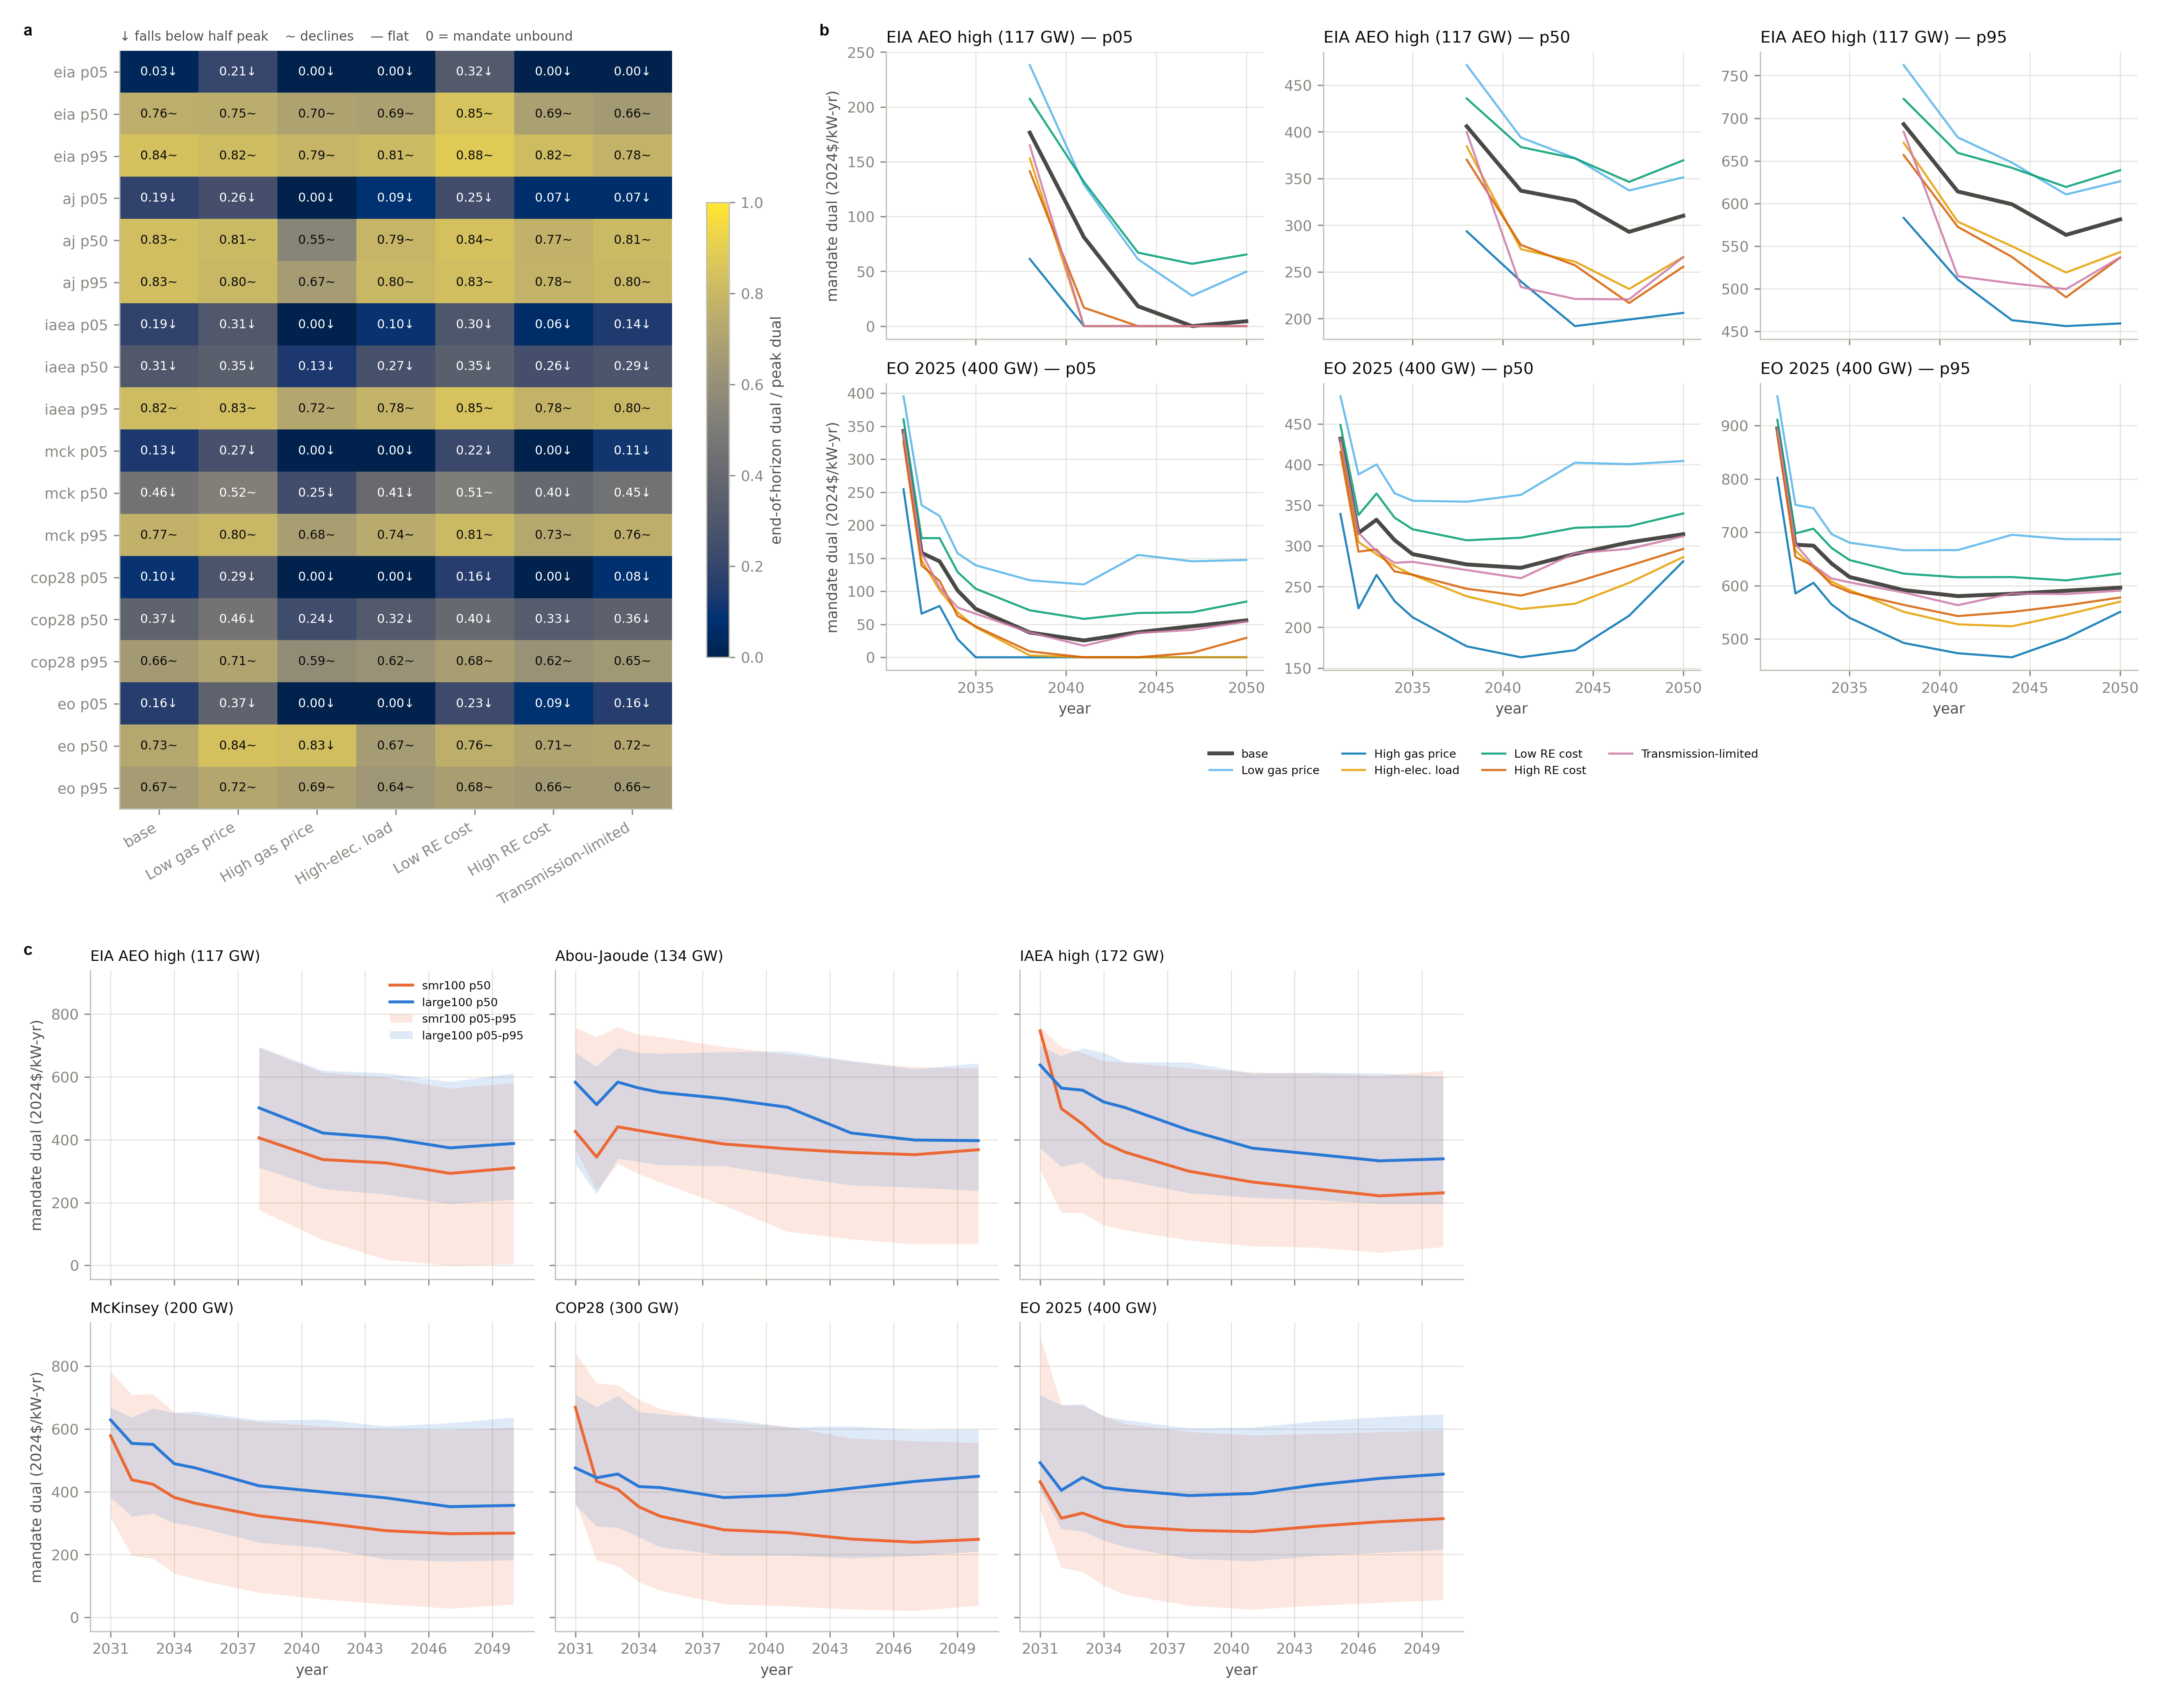

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step4_analysis\figures\g02_shape_survival_matrix.png` — generated by `step4_analysis/step4_analysis.ipynb` (cell 11) from `step4_analysis/exports/s02_shape_survival.csv`
- `z-ethan\step4_analysis\figures\g03_dual_overlays.png` — generated by `step4_analysis/step4_analysis.ipynb` (cell 12) from step3+step4 checks `duals_by_year.csv` (eia/eo x p05/p50/p95 x 7 arms)
- `z-ethan\step3_analysis\figures\f15_large_band.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 23) from combined duals, large100 vs smr100 shared binding years; table: `t15_large_ratio.csv`

shape survival: 108/108
Kendall tau vs base (fiscal-bill metric, 18 non-base cells): min 0.867, mean 0.993
      min   max
pct            
p05  1.44  3.53
p50  1.23  1.36
p95  0.95  1.02

--- draft caption [Fig 6] ---
Robustness across market worlds (108 sensitivity runs: 18 cases x six market arms). (a) Bridge-
shape survival matrix: the shape survives in 108 of 108 cells — the expensive-world non-decay is
generic. (b) Dual overlays for the ladder's end schedules across market worlds: only the level
moves, in the direction economics predicts (median -27% to +18%). (c) Large-reactor vs SMR duals
by percentile: the large premium is 1.4-3.5x in cheap worlds and 1.23-1.36x at the median, but
the two technologies reach parity (0.95-1.02x) in expensive worlds.


In [7]:
P.compose(
    [[S4_FIG / "g02_shape_survival_matrix.png", S4_FIG / "g03_dual_overlays.png"],
     [S3_FIG / "f15_large_band.png"]],
    "Fig6_robustness.png",
)
P.source_ref(
    (S4_FIG / "g02_shape_survival_matrix.png", "step4_analysis/step4_analysis.ipynb", "cell 11",
     "`step4_analysis/exports/s02_shape_survival.csv`"),
    (S4_FIG / "g03_dual_overlays.png", "step4_analysis/step4_analysis.ipynb", "cell 12",
     "step3+step4 checks `duals_by_year.csv` (eia/eo x p05/p50/p95 x 7 arms)"),
    (S3_FIG / "f15_large_band.png", "step3_analysis/step3_analysis.ipynb", "cell 23",
     "combined duals, large100 vs smr100 shared binding years; table: `t15_large_ratio.csv`"),
)

s02 = pd.read_csv(S4_EXP / "s02_shape_survival.csv")
surv = s02[s02["survives"].notna()]
n_surv = int((surv["survives"] == "yes").sum())
print(f"shape survival: {n_surv}/{len(surv)}")
s03 = pd.read_csv(S4_EXP / "s03_ranking_preservation.csv")
fis = s03[(s03["metric"] == "disc_program_bill") & (s03["sens"] != "base")]
print(f"Kendall tau vs base (fiscal-bill metric, 18 non-base cells): "
      f"min {fis['kendall_tau_vs_base'].min():.3f}, "
      f"mean {fis['kendall_tau_vs_base'].mean():.3f}")
t15 = pd.read_csv(S3_EXP / "t15_large_ratio.csv")
print(t15.groupby("pct")["ratio_large_over_smr"].agg(["min", "max"]).round(2).to_string())

P.caption("Fig 6", f'''
Robustness across market worlds (108 sensitivity runs: 18 cases x six market arms).
(a) Bridge-shape survival matrix: the shape survives in {n_surv} of
{len(surv)} cells — the expensive-world non-decay is generic. (b) Dual overlays for the
ladder's end schedules across market worlds: only the level moves, in the direction
economics predicts (median -27% to +18%). (c) Large-reactor vs SMR duals by percentile:
the large premium is 1.4-3.5x in cheap worlds and 1.23-1.36x at the median, but the two
technologies reach parity (0.95-1.02x) in expensive worlds.
''')

## Table 1 — Case-level results: dual level, bridge shape, required rate

**What this shows.** One row per priced run (37 runs: 25 SMR-program cases
and 12 large-reactor comparators). Three groups of columns:
- **Dual level** (from `t03`): number of binding years, mean binding dual,
  peak dual and its year, and the 2050 dual — all 2024\$/kW-yr.
- **Bridge shape** (from `t04`): end-over-peak ratio, the first year the
  dual falls below half its peak (blank = never by 2050), and mandated
  years with a zero dual ("needs no subsidy" years — a legitimate outcome
  we report with the same prominence).
- **Required ITC rate** (from `t09`, model convention): the number of rated
  years, the mean and maximum headline rate, and how many years exceed
  100%.

**How to read a row.** Case names are `family_schedule_percentile`:
for example `smr100_eo_p95` = the 100%-SMR program, EO schedule (400 GW),
expensive world. Compare `end_over_peak` down the percentile column to see
the bridge result; compare `i_model_mean` against 0.30 (the base credit)
for the policy gap.

In [8]:
t03 = pd.read_csv(S3_EXP / "t03_dual_summary.csv")
t04 = pd.read_csv(S3_EXP / "t04_bridge_metrics.csv")
t09 = pd.read_csv(S3_EXP / "t09_required_itc.csv")

rated = t09[t09["status"] == "rate"]
rate_agg = (rated.groupby("case")
            .agg(rated_years=("t", "count"),
                 i_model_mean=("i_model_headline", "mean"),
                 i_model_max=("i_model_headline", "max"),
                 years_over_100pct=("i_model_headline", lambda s: int((s > 1.0).sum())))
            .reset_index())

table1 = (t03
          .merge(t04.drop(columns=["peak_year"]), on="case")
          .merge(rate_agg, on="case", how="left"))
table1 = table1.round({"mean_binding_dual_2024_kWyr": 0, "peak_dual_2024_kWyr": 0,
                       "dual_2050_2024_kWyr": 0, "end_over_peak": 2,
                       "i_model_mean": 2, "i_model_max": 2})
table1.to_csv(P.OUT_EXP / "Table1_case_level_results.csv", index=False)
print(f"exports/Table1_case_level_results.csv ({len(table1)} rows)")

P.caption("Table 1", '''
Case-level results for all 37 priced runs. Dual level (binding years; mean, peak, and
2050 dual, 2024$/kW-yr), bridge-shape metrics (end-over-peak; first year below half-peak,
blank = never by 2050; zero-dual mandated years), and the required ITC rate on the model
convention (mean and maximum headline rate over rated years; years above 100%). Sources:
t03_dual_summary, t04_bridge_metrics, t09_required_itc (model convention).
''')
table1

exports/Table1_case_level_results.csv (37 rows)

--- draft caption [Table 1] ---
Case-level results for all 37 priced runs. Dual level (binding years; mean, peak, and 2050 dual,
2024$/kW-yr), bridge-shape metrics (end-over-peak; first year below half-peak, blank = never by
2050; zero-dual mandated years), and the required ITC rate on the model convention (mean and
maximum headline rate over rated years; years above 100%). Sources: t03_dual_summary,
t04_bridge_metrics, t09_required_itc (model convention).


,case,n_binding,mean_binding_dual_2024_kWyr,peak_dual_2024_kWyr,peak_year,dual_2050_2024_kWyr,end_over_peak,first_year_below_half_peak,n_zero_dual_mandated_years,rated_years,i_model_mean,i_model_max,years_over_100pct
0,smr100_eia_p05,4,70.0,176.0,2038,4.0,0.03,2041.0,1,4,0.19,0.45,0
1,smr100_eia_p50,5,334.0,406.0,2038,310.0,0.76,NaN,0,5,0.59,0.70,0
2,smr100_eia_p95,5,610.0,693.0,2038,581.0,0.84,NaN,0,5,0.80,0.87,0
3,smr100_aj_p05,10,201.0,371.0,2031,69.0,0.19,2041.0,0,10,0.39,0.57,0
4,smr100_aj_p50,10,390.0,441.0,2033,368.0,0.83,NaN,0,10,0.62,0.70,0
5,smr100_aj_p95,10,698.0,759.0,2033,628.0,0.83,NaN,0,10,0.83,0.90,0
6,smr100_iaea_p05,10,118.0,306.0,2031,59.0,0.19,2034.0,0,10,0.30,0.56,0
7,smr100_iaea_p50,10,371.0,746.0,2031,231.0,0.31,2035.0,0,10,0.71,0.84,0
8,smr100_iaea_p95,10,650.0,759.0,2031,620.0,0.82,NaN,0,10,0.85,0.90,0
9,smr100_mck_p05,10,121.0,318.0,2031,41.0,0.13,2034.0,0,10,0.31,0.58,0


## Table 2 (reserve) — The fiscal comparison

**What this shows.** Two present-value fiscal totals per case, 2026–2050,
in billions of 2024 dollars, and their ratio:
- **PV rental transfer**: the benchmark of paying the dual directly, each
  year, on the program's mandated post-2030 capacity (the fleet-inclusive
  large100 mandates are netted of the pre-existing fleet).
- **PV ITC outlay**: what delivering the same support through the
  investment tax credit costs the treasury, gross (face value accrued to
  commissioning — invariant to the 08-18 convention revision).

**How to read it.** The ratio column is the point: an outlay-over-rental
ratio near 1 means the credit delivers the rental value roughly
dollar-for-dollar; above 1 means the instrument costs more than the
support it delivers. The net-of-tax instrument comparison (which reverses
the gross ranking) is in the appendix notebook (SF11b).

**Status.** The outline holds this slot in reserve: it ships if the word
count allows the schedule facts of the introduction to stay in prose;
otherwise the schedules table replaces it.

In [9]:
table2 = P.table(S3_EXP / "t12_fiscal_comparison.csv", "Table2_fiscal_comparison.csv",
                 index_col=0, round_=2)
P.caption("Table 2", '''
Fiscal totals per case, 2026-2050 (billion 2024$, present value): the rental-transfer
benchmark (paying the dual directly each year on the program's post-2030 capacity),
the gross ITC outlay (face value accrued to commissioning), and their ratio. Source:
t12_fiscal_comparison.
''')
table2

z-ethan\step3_analysis\exports\t12_fiscal_comparison.csv -> exports/Table2_fiscal_comparison.csv

--- draft caption [Table 2] ---
Fiscal totals per case, 2026-2050 (billion 2024$, present value): the rental-transfer benchmark
(paying the dual directly each year on the program's post-2030 capacity), the gross ITC outlay
(face value accrued to commissioning), and their ratio. Source: t12_fiscal_comparison.


,PV_ITC_outlay_2024B,PV_rental_transfer_2024B,outlay_over_rental
case,,,
large100_aj_p05,60.9,23.4,2.60
large100_aj_p50,100.4,39.3,2.55
large100_aj_p95,143.8,57.3,2.51
large100_cop28_p05,300.7,143.5,2.10
large100_cop28_p50,575.7,291.0,1.98
large100_cop28_p95,839.3,430.3,1.95
large100_eia_p05,42.1,21.9,1.92
large100_eia_p50,69.6,38.5,1.81
large100_eia_p95,96.0,57.2,1.68


## Output manifest

Everything this notebook wrote, in one list. The composed figures are in
`figures/`; the tables and the draft captions are in `exports/`.

In [10]:
P.write_captions("main")
for f in sorted(P.OUT_FIG.glob("Fig*.png")):
    print(f"figures/{f.name}")
for f in sorted(P.OUT_EXP.glob("Table*.csv")):
    print(f"exports/{f.name}")

8 captions -> z-ethan\paper_figures\exports\captions_main.txt
figures/Fig1_schedules_and_cost_fans.png
figures/Fig2_smr_conditioning.png
figures/Fig3_required_subsidy_bridge.png
figures/Fig4_required_itc_and_menu.png
figures/Fig5_atb_inversion.png
figures/Fig6_robustness.png
exports/Table1_case_level_results.csv
exports/Table2_fiscal_comparison.csv
